# Benchmark for Obstacle Problem 1D

In [2]:
"""
Gaussian-RBF ADMM solver for 1-D obstacle problems (variational form)
- float32 core for speed; float64 tSVD pseudo-inverse for stability
- Hard tSVD threshold tau (default 1e-15)
- Condition-number cap on the pseudo-inverse
- Early stopping on stalled primal/dual progress
"""

from __future__ import annotations
import numpy as np
from numba import njit, prange
from typing import Dict, Literal, Tuple, Optional

# -----------------------------
# Default numeric types / guards
# -----------------------------
DTYPE = np.float32
TINY  = np.float32(1e-30)

# -----------------------------
# Problem definitions
# -----------------------------
def _psi1(x: np.ndarray) -> np.ndarray:
    x  = np.asarray(x, dtype=DTYPE)
    y  = np.zeros_like(x)
    m1 = x <= DTYPE(0.25)
    m2 = (x > DTYPE(0.25)) & (x <= DTYPE(0.5))
    m3 = x > DTYPE(0.5)
    y[m1] = DTYPE(100.0)*x[m1]**DTYPE(2.0)
    y[m2] = DTYPE(100.0)*x[m2]*(1-x[m2]) - DTYPE(12.5)
    xs    = 1 - x[m3]
    y[m3] = np.where(xs <= DTYPE(0.25),
                     DTYPE(100.0)*xs**DTYPE(2.0),
                     DTYPE(100.0)*xs*(1-xs) - DTYPE(12.5))
    return y

def _u1_exact(x: np.ndarray) -> np.ndarray:
    x  = np.asarray(x, dtype=DTYPE)
    y  = np.zeros_like(x)
    xc = DTYPE(1.0)/(DTYPE(2.0)*np.sqrt(DTYPE(2.0)))
    m1 = x <= xc
    m2 = (x > xc) & (x <= DTYPE(0.5))
    m3 = x > DTYPE(0.5)
    y[m1] = (DTYPE(100.0)-DTYPE(50.0)*np.sqrt(DTYPE(2.0)))*x[m1]
    y[m2] = DTYPE(100.0)*x[m2]*(1-x[m2]) - DTYPE(12.5)
    xs    = 1 - x[m3]
    y[m3] = np.where(xs <= xc,
                     (DTYPE(100.0)-DTYPE(50.0)*np.sqrt(DTYPE(2.0)))*xs,
                     DTYPE(100.0)*xs*(1-xs) - DTYPE(12.5))
    return y

def _psi2(x: np.ndarray) -> np.ndarray:
    x  = np.asarray(x, dtype=DTYPE)
    y  = np.zeros_like(x)
    m1 = x <= DTYPE(0.25)
    m2 = (x > DTYPE(0.25)) & (x <= DTYPE(0.5))
    m3 = x > DTYPE(0.5)
    y[m1] = DTYPE(10.0)*np.sin(DTYPE(2.0)*np.pi*x[m1])
    y[m2] = DTYPE(5.0)*np.cos(np.pi*(DTYPE(4.0)*x[m2]-DTYPE(1.0))) + DTYPE(5.0)
    xs    = 1 - x[m3]
    y[m3] = np.where(xs <= DTYPE(0.25),
                     DTYPE(10.0)*np.sin(DTYPE(2.0)*np.pi*xs),
                     DTYPE(5.0)*np.cos(np.pi*(DTYPE(4.0)*xs-DTYPE(1.0))) + DTYPE(5.0))
    return y

def _u2_exact(x: np.ndarray) -> np.ndarray:
    x  = np.asarray(x, dtype=DTYPE)
    y  = np.zeros_like(x)
    m1 = x <= DTYPE(0.25)
    m2 = (x > DTYPE(0.25)) & (x <= DTYPE(0.5))
    m3 = x > DTYPE(0.5)
    y[m1] = DTYPE(10.0)*np.sin(DTYPE(2.0)*np.pi*x[m1])
    y[m2] = DTYPE(10.0)
    xs    = 1 - x[m3]
    y[m3] = np.where(xs <= DTYPE(0.25),
                     DTYPE(10.0)*np.sin(DTYPE(2.0)*np.pi*xs),
                     DTYPE(10.0))
    return y

# -----------------------------
# RBF scale from (T, tau)
# -----------------------------
def c_from_T_tau(T: float, tau: float) -> float:
    """c(T, τ) used to set Gaussian shape b = c * N."""
    return float(np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2)))))

# -----------------------------
# Numba kernels (float32)
# -----------------------------
@njit(fastmath=True, parallel=True)
def _phi_matrix(b: float, N: int, x: np.ndarray, centres: np.ndarray) -> np.ndarray:
    m   = x.size
    phi = np.empty((m, N), dtype=DTYPE)
    b2  = DTYPE(b*b)
    inv = DTYPE(1.0)/np.sqrt(DTYPE(N))
    for i in prange(m):
        xi = x[i]
        for j in range(N):
            d = xi - centres[j]
            phi[i, j] = np.exp(-b2*d*d)*inv
    return phi

@njit(fastmath=True, parallel=True)
def _dphi_matrix(b: float, N: int, x: np.ndarray, centres: np.ndarray) -> np.ndarray:
    m    = x.size
    dphi = np.empty((m, N), dtype=DTYPE)
    b2   = DTYPE(b*b)
    two  = DTYPE(2.0)*b2
    inv  = DTYPE(1.0)/np.sqrt(DTYPE(N))
    for i in prange(m):
        xi = x[i]
        for j in range(N):
            d    = xi - centres[j]
            expv = np.exp(-b2*d*d)
            dphi[i, j] = (-two*d)*expv*inv
    return dphi

# -----------------------------
# ADMM loop (float32 core; float64 tSVD solve)
# -----------------------------
@njit(fastmath=False, error_model='numpy')
def _admm_loop(phi, phiT, psi, u_true,
               mu, rho, dx, max_iter, tol, norm_u2,
               U64, S_inv64, VT64, rhs_const64,
               over_relax_alpha, tiny,
               stall_rel, stall_patience,
               trap_w):
    N = phi.shape[1]
    M = phi.shape[0]

    w = np.zeros(N, dtype=np.float32)
    v = np.zeros(M, dtype=np.float32)
    z = np.zeros(M, dtype=np.float32)
    Pw = np.zeros(M, dtype=np.float32)
    v_prev = np.zeros(M, dtype=np.float32)

    prim_log = np.empty(max_iter, dtype=np.float32)
    dual_log = np.empty(max_iter, dtype=np.float32)
    l2_log   = np.empty(max_iter, dtype=np.float32)

    safe_rho = np.float32(rho) if rho != 0 else tiny
    ratio    = (np.float32(mu) * dx) / safe_rho

    best_prim = np.float32(1e30)
    best_dual = np.float32(1e30)
    stall_cnt = 0

    for it in range(max_iter):
        # w-update (float64 via tSVD with condition cap)
        rhs32 = safe_rho * (phiT @ (v - z))
        rhs64 = rhs32.astype(np.float64) + rhs_const64
        tmp1  = U64.T @ rhs64
        for k in range(tmp1.size):
            tmp1[k] = tmp1[k] * S_inv64[k]
        w64  = VT64.T @ tmp1
        w[:] = w64.astype(np.float32)

        # v-update with obstacle + shrink
        Pw[:] = phi @ w
        t = over_relax_alpha * Pw + (np.float32(1.0) - over_relax_alpha) * v + z
        for i in range(M):
            if t[i] < psi[i]:
                cand = t[i] - ratio
                v[i] = psi[i] if (cand < psi[i]) else cand
            else:
                v[i] = t[i]

        # z-update
        z += Pw - v

        # diagnostics
        r_k = Pw - v
        s_vec = v - v_prev
        v_prev[:] = v

        nu = Pw @ Pw;  nv = v @ v
        if not np.isfinite(nu) or nu < tiny: nu = tiny
        if not np.isfinite(nv) or nv < tiny: nv = tiny
        den_prim = np.sqrt(nu) if np.sqrt(nu) > np.sqrt(nv) else np.sqrt(nv)
        if den_prim < tiny or not np.isfinite(den_prim): den_prim = tiny
        prim = r_k @ r_k / den_prim

        s_k = safe_rho * (phiT @ s_vec)
        dual_denom = np.linalg.norm(safe_rho * (phiT @ z))
        if not np.isfinite(dual_denom) or dual_denom < tiny: dual_denom = tiny
        dual = np.linalg.norm(s_k ** 2) / dual_denom

        # relative L2 via trapezoid (correctly ∫|u-u*|^2)
        diff  = Pw - u_true
        diff2 = diff * diff
        l2num = dx * (trap_w @ diff2 ** 2)          # == np.trapz(diff**2, x)
        if not np.isfinite(l2num) or l2num < 0.0:
            l2num = 0.0
        l2rel = l2num / norm_u2

        prim_log[it] = prim
        dual_log[it] = dual
        l2_log[it]   = l2rel

        # convergence
        if prim < np.float32(tol) and dual < np.float32(tol):
            return w, it+1, prim_log[:it+1], dual_log[:it+1], l2_log[:it+1]

        # early-stopping (stall)
        imp_prim = (best_prim - prim) / (best_prim if best_prim > tiny else tiny)
        imp_dual = (best_dual - dual) / (best_dual if best_dual > tiny else tiny)
        improved = False
        if imp_prim > stall_rel:
            best_prim = prim; improved = True
        if imp_dual > stall_rel:
            best_dual = dual; improved = True
        if improved:
            stall_cnt = 0
        else:
            stall_cnt += 1
            if stall_cnt >= stall_patience:
                return w, it+1, prim_log[:it+1], dual_log[:it+1], l2_log[:it+1]

    return w, max_iter, prim_log, dual_log, l2_log

# -----------------------------
# Public solver
# -----------------------------
def solve_obstacle_rbf_admm(
    problem: Literal["1","2"] = "2",
    N: int = 512,
    zeta: float = 2.0,
    T_kernel: float = 12.0,        # used in c(T, τ) to set b = c*N
    T_cent: float = 1.0,           # domain expansion for centers around [0,1]
    tau: float = 1e-15,
    mu: float = 2.5e4,             # default for problem '2' (else 300.0)
    rho: float = 250.0,            # default for problem '2' (else 45.0)
    beta_bc: float = 3e5,
    h_bc: float = 1e-6,
    max_iter: int = 50_000,
    tol: float = 5e-8,
    over_relax_alpha: float = 1.0,
    kappa_max: float = 1e10,
    stall_rel: float = 1e-3,
    stall_patience: int = 5000,
    return_mats: bool = False,
    c_override: float | None = None,   # <<< NEW
) -> Dict[str, np.ndarray | float | int]:
    """
    Solve 1-D obstacle problem with Gaussian-RBF ADMM.

    Returns a dict containing:
      - 'x', 'u_true', 'psi', 'u_final'
      - 'w', 'phi' (if return_mats), 'centres'
      - 'prim', 'dual', 'relL2', 'iters'
      - 'b', 'c', 'T_kernel', 'T_cent', 'tau', 'N', 'zeta'
    """
    # Mesh & centers
    M        = int(np.round(zeta * N))
    x        = np.linspace(0.0, 1.0, M, dtype=DTYPE)
    lower_a, upper_b = DTYPE(0.0), DTYPE(1.0)
    L = DTYPE(0.5) * (upper_b - lower_a)
    q = DTYPE(0.5) * (lower_a + upper_b)
    T_cent = DTYPE(T_cent)
    centres = np.linspace(q - T_cent * L, q + T_cent * L, N, dtype=DTYPE)
    dx       = DTYPE(x[1] - x[0])

    # Problem data
    if problem == "1":
        psi    = _psi1(x); u_true = _u1_exact(x)
        mu_def, rho_def = 300.0, 45.0
    else:
        psi    = _psi2(x); u_true = _u2_exact(x)
        mu_def, rho_def = 2.5e4, 250.0
    if mu is None:  mu = mu_def
    if rho is None: rho = rho_def
    u0, u1b = DTYPE(u_true[0]), DTYPE(u_true[-1])

    # RBF scale: b = c * N
    if c_override is None:
        c_val = c_from_T_tau(T_kernel, tau)
    else:
        c_val = float(c_override)      # <<< NEW
    b = c_val * N


    # Basis & derivatives
    phi  = _phi_matrix(b, N, x, centres)
    dphi = _dphi_matrix(b, N, x, centres)
    phiT = phi.T.copy()

    # System matrices (float32)
    A1    = (dphi.T @ dphi) * dx
    beta  = DTYPE(beta_bc)
    hbc   = DTYPE(h_bc)
    idx0  = np.where(x <= hbc)[0]
    idx1  = np.where(x >= (DTYPE(1.0)-hbc))[0]
    phi0  = phi[idx0]
    phi1b = phi[idx1]

    u0_vec = np.full(len(idx0), u0, dtype=DTYPE)
    u1_vec = np.full(len(idx1), u1b, dtype=DTYPE)
    W0     = (dx * np.eye(len(idx0), dtype=DTYPE))
    W1     = (dx * np.eye(len(idx1), dtype=DTYPE))

    A      = A1 + beta*(phi0.T @ W0 @ phi0 + phi1b.T @ W1 @ phi1b)
    lhs    = A + DTYPE(rho)*(phiT @ phi)

    # RHS constant term for w-update
    rhs_const   = beta*(phi0.T @ (W0 @ u0_vec) + phi1b.T @ (W1 @ u1_vec))
    rhs_const64 = rhs_const.astype(np.float64, copy=True)

    # tSVD (float64) with tau and kappa cap
    U64, S64, VT64 = np.linalg.svd(lhs.astype(np.float64), full_matrices=False)
    thresh = float(tau) * float(np.max(S64))
    keep   = S64 > thresh
    if not np.any(keep):
        keep = np.zeros_like(S64, dtype=bool)
        keep[np.argmax(S64)] = True
    U64  = U64[:, keep]
    S64  = S64[keep]
    VT64 = VT64[keep, :]

    Smax = float(np.max(S64))
    Smin_allowed = Smax / float(kappa_max)
    Seff64 = np.maximum(S64, Smin_allowed)
    S_inv64 = 1.0 / Seff64

    # Trapezoid weights & denominator
    trap_w = np.ones_like(x, dtype=DTYPE)
    trap_w[0]  = DTYPE(0.5)
    trap_w[-1] = DTYPE(0.5)
    norm_u2 = np.trapz((u_true.astype(np.float64))**2, x.astype(np.float64)).astype(DTYPE)
    if not np.isfinite(norm_u2) or norm_u2 <= TINY:
        norm_u2 = TINY

    # ADMM
    w_sol, it_conv, prim, dual, relL2 = _admm_loop(
        phi, phiT, psi, u_true,
        np.float32(mu), np.float32(rho), dx, max_iter, np.float32(tol), norm_u2,
        U64, S_inv64, VT64, rhs_const64,
        np.float32(over_relax_alpha), TINY,
        np.float32(stall_rel), np.int32(stall_patience),
        trap_w
    )

    u_final = phi @ w_sol

    out: Dict[str, np.ndarray | float | int] = {
        "x": x, "u_true": u_true, "psi": psi, "u_final": u_final,
        "w": w_sol, "centres": centres,
        "prim": prim, "dual": dual, "relL2": relL2, "iters": int(it_conv),
        "b": float(b), "c": float(c_val), "T_kernel": float(T_kernel), "T_cent": float(T_cent),
        "tau": float(tau), "N": int(N), "zeta": float(zeta),
        "mu": float(mu), "rho": float(rho), "beta_bc": float(beta_bc),
    }
    if return_mats:
        out["phi"]  = phi
        out["dphi"] = dphi
    return out




def rbf_obstacle_relL2(
    N: int,
    T_kernel: float,
    *,
    problem: str = "2",
    zeta: float = 2.0,
    T_cent: float = 1.2,
    tau: float = 1e-15,
    mu: float | None = None,
    rho: float | None = None,
    beta_bc: float = 3e5,
    h_bc: float = 1e-6,
    max_iter: int = 50_000,
    tol: float = 5e-8,
    over_relax_alpha: float = 1.0,
    kappa_max: float = 1e10,
    stall_rel: float = 1e-3,
    stall_patience: int = 2000,
) -> tuple[float, int, float]:
    """
    Run once and return (final_relative_L2_error, N, T_kernel).
    The relative L2 error inside the solver is computed with np.trapz.
    """
    res = solve_obstacle_rbf_admm(
        problem=problem,
        N=N,
        zeta=zeta,
        T_kernel=T_kernel,
        T_cent=T_cent,
        tau=tau,
        mu=mu,
        rho=rho,
        beta_bc=beta_bc,
        h_bc=h_bc,
        max_iter=max_iter,
        tol=tol,
        over_relax_alpha=over_relax_alpha,
        kappa_max=kappa_max,
        stall_rel=stall_rel,
        stall_patience=stall_patience,
        return_mats=False,
    )
    relL2_final = float(res["relL2"][-1]) 
    return relL2_final, int(N), float(T_kernel)



def rbf_obstacle_relL2_from_c(
    N: int,
    c: float,
    *,
    T_kernel_fixed: float,
    problem: str = "1",
    zeta: float = 2.0,
    T_cent: float = 1.2,
    tau: float = 1e-15,
    mu: float | None = None,
    rho: float | None = None,
    beta_bc: float = 3e5,
    h_bc: float = 1e-6,
    max_iter: int = 50_000,
    tol: float = 5e-8,
    over_relax_alpha: float = 1.0,
    kappa_max: float = 1e10,
    stall_rel: float = 1e-3,
    stall_patience: int = 2000,
) -> tuple[float, int, float, float]:
    """
    Return (final_relative_L2_error, N, T_kernel_fixed, c) with np.trapz inside solver.
    """
    res = solve_obstacle_rbf_admm(
        problem=problem,
        N=N,
        zeta=zeta,
        T_kernel=T_kernel_fixed,
        T_cent=T_cent,
        tau=tau,
        mu=mu,
        rho=rho,
        beta_bc=beta_bc,
        h_bc=h_bc,
        max_iter=max_iter,
        tol=tol,
        over_relax_alpha=over_relax_alpha,
        kappa_max=kappa_max,
        stall_rel=stall_rel,
        stall_patience=stall_patience,
        return_mats=False,
        c_override=c,                 # <<< use explicit c
    )
    return float(res["relL2"][-1]), int(N), float(T_kernel_fixed), float(c)



def monotone_nonincreasing(y: np.ndarray, strict: bool = False, rel_eps: float = 1e-9) -> np.ndarray:
    """
      y[i] <- min(y[i], y[i-1]) (or y[i-1]*(1-rel_eps) if strict).
    Invalid/zero/negative entries are replaced by the previous valid value.
    """
    out = np.array(y, dtype=float, copy=True)
    # Initialize first value: if invalid, fall back to 1.0 (or the smallest positive finite in y)
    if not np.isfinite(out[0]) or out[0] <= 0.0:
        finite_pos = out[np.isfinite(out) & (out > 0.0)]
        out[0] = float(finite_pos[0]) if finite_pos.size else 1.0

    for i in range(1, out.size):
        v = out[i]
        if not np.isfinite(v) or v <= 0.0:
            v = out[i-1] if not strict else out[i-1] * (1.0 - rel_eps)
        # cap upward wiggles
        cap = out[i-1] if not strict else out[i-1] * (1.0 - rel_eps)
        out[i] = v if v <= cap else cap
    return out


# Benchmark for T expansion factor

Running rbf_obstacle_relL2 grid ...

T_kernel = 1
  N=   8  relL2=0.000e+00  time=0.002s
  N=  16  relL2=1.311e+01  time=0.025s
  N=  32  relL2=0.000e+00  time=0.013s
  N=  64  relL2=5.133e-04  time=0.019s
  N= 128  relL2=0.000e+00  time=0.012s
  N= 256  relL2=0.000e+00  time=0.014s
  N= 512  relL2=4.961e-09  time=0.341s
  N=1024  relL2=0.000e+00  time=0.107s
  N=2048  relL2=0.000e+00  time=0.326s
  N=4096  relL2=0.000e+00  time=1.813s

T_kernel = 1.5
  N=   8  relL2=0.000e+00  time=0.003s
  N=  16  relL2=1.462e+01  time=0.010s
  N=  32  relL2=7.888e+00  time=0.003s
  N=  64  relL2=1.832e+01  time=0.006s
  N= 128  relL2=5.642e-04  time=0.015s
  N= 256  relL2=2.365e-06  time=0.026s
  N= 512  relL2=2.030e-08  time=0.160s
  N=1024  relL2=7.267e-10  time=1.232s
  N=2048  relL2=0.000e+00  time=0.411s
  N=4096  relL2=0.000e+00  time=1.023s

T_kernel = 2
  N=   8  relL2=0.000e+00  time=0.004s
  N=  16  relL2=1.527e+01  time=0.010s
  N=  32  relL2=0.000e+00  time=0.007s
  N=  64  relL2=0.000e+

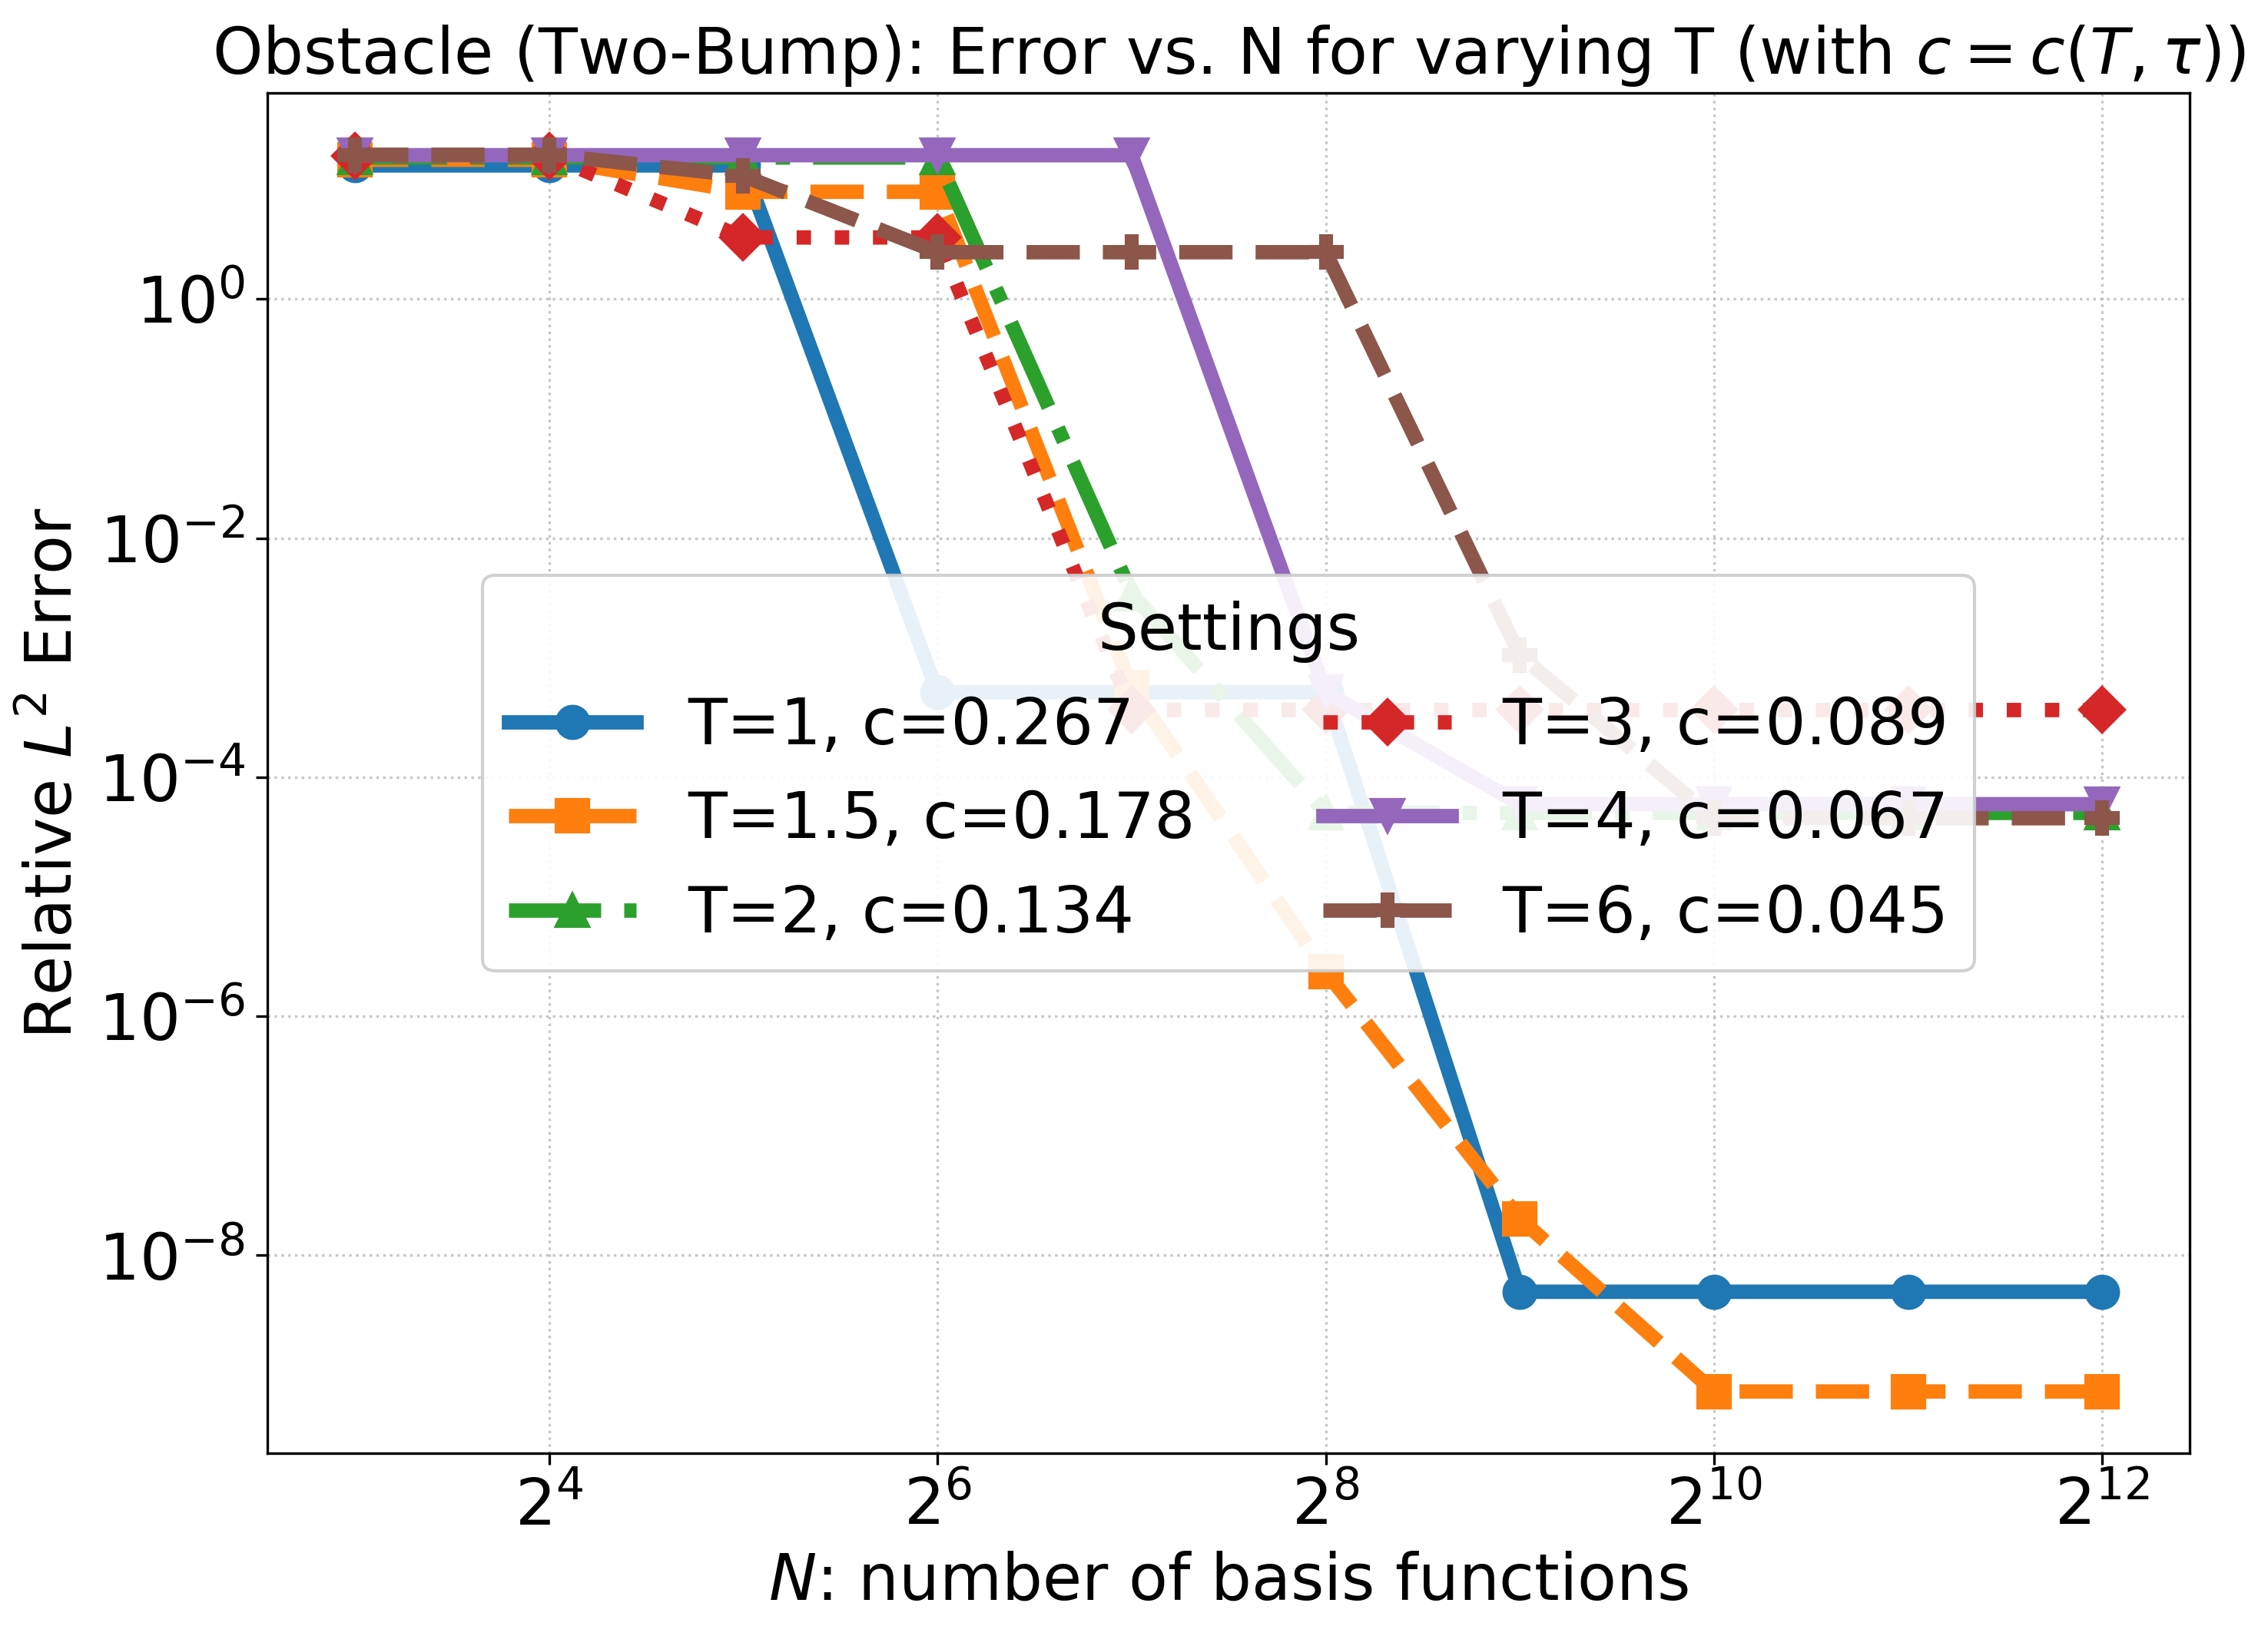

In [5]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from itertools import cycle

# If not already imported:
# from your_module import rbf_obstacle_relL2

# ----------------------------
# Global plotting style (your rcParams)
# ----------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "legend.fontsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "lines.linewidth": 4.5,
    "lines.markersize": 20,
    "grid.alpha": 0.7,
    "figure.dpi": 300
})

# =======================
# Config
# =======================
N_values = np.array([8, 16, 32, 64, 128, 256, 512, 1024,2048, 4096], dtype=int)
T_values = np.array([1.0, 1.5, 2.0, 3.0, 4.0, 6.0], dtype=float) # for problem 1. 
# --- put this near your config ---
def c_from_T_tau(T: float, tau: float) -> float:
    return float(np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2)))))

tau_used = 1e-15  # must match the tau used inside rbf_obstacle_relL2
c_map = {float(T): c_from_T_tau(float(T), tau_used) for T in T_values}

problem  = "2"   # "1" -> One-Bump, "2" -> Two-Bump

# Dynamic title and output directory based on problem
title_map = {
    "1": r"Obstacle (One-Bump): Error vs. N for varying T (with $c=c(T,\tau)$)",
    "2": r"Obstacle (Two-Bump): Error vs. N for varying T (with $c=c(T,\tau)$)"
}
subdir_map = {"1": "Problem1", "2": "Problem2"}

base_dir = "./Outputs/1D_Obstacle"
out_dir  = os.path.join(base_dir, subdir_map.get(problem, "Problem1"))
os.makedirs(out_dir, exist_ok=True)
N_values_plot = N_values
N_values = N_values//8
out_path = os.path.join(out_dir, "fig1_obstacle.png")

legend_ncols = 2

# =======================
# Run experiments
# =======================
E = {}       # T_kernel -> array of rel L2 error vs N
Times = {}   # T_kernel -> array of elapsed times vs N

print("Running rbf_obstacle_relL2 grid ...")
for T in T_values:
    errs, times = [], []
    print(f"\nT_kernel = {T:g}")
    for (N, N_plot) in zip(N_values, N_values_plot):
        t0 = time.perf_counter()
        if (T > 3.0):
            rel_err, N_out, T_out = rbf_obstacle_relL2(
                N=N,
                T_kernel=float(T),
                T_cent = 1.0, 
                problem=problem,   # keep other params at solver defaults
                )
        else: 
            rel_err, N_out, T_out = rbf_obstacle_relL2(
                N=N,
                T_kernel=float(T), 
                T_cent = 1.0,
                problem=problem,   # keep other params at solver defaults
                )            
        dt = time.perf_counter() - t0
        if N_out != N or abs(T_out - T) > 1e-12:
            print(f"  [warn] returned (N={N_out}, T={T_out}) for request (N={N}, T={T})")
        errs.append(float(rel_err))
        times.append(float(dt))
        print(f"  N={N_plot:4d}  relL2={float(rel_err):.3e}  time={dt:.3f}s")

    E[float(T)]     = np.asarray(errs, dtype=float)
    Times[float(T)] = np.asarray(times, dtype=float)





# =======================
# Plot E(N) vs N for each T_kernel
# =======================
from itertools import cycle
import matplotlib.pyplot as plt

marker_cycle    = cycle(['o', 's', '^', 'D', 'v', 'P', 'X', '*'])
linestyle_cycle = cycle(['-', '--', '-.', ':'])

#EPS = np.finfo(float).eps  
EPS = 1e-8

fig, ax = plt.subplots(figsize=(10, 7.5))
for T in T_values:
    y_raw = np.asarray(E[float(T)], dtype=float)
    y = monotone_nonincreasing(y_raw, strict=True)
    #y = np.where(np.isfinite(y) & (y > 0.0), y, EPS)
    
    c_val = c_map[float(T)]
    ax.plot(
        N_values_plot, y,
        marker=next(marker_cycle),
        linestyle=next(linestyle_cycle),
        markersize=10,
        # choose .3f or .3e depending on how small c is
        label=f"T={T:g}, c={c_val:.3f}"
        # label=f"T={T:g}, c={c_val:.3e}"  # <- use this if you prefer scientific
    )


# Axes: log scales, with x-ticks exactly at N_values
ax.set_xscale('log', base=2)         # N doubles
ax.set_yscale('log')                 # errors often geometric

# Force ticks/labels to the exact N set
#ax.set_xticks(N_values)
#ax.set_xticklabels([str(n) for n in N_values])
#ax.tick_params(axis='x', which='major', width=1.2, length=6)
#ax.tick_params(axis='x', which='minor', bottom=False)  # hide minor x ticks

# Nice padding so end ticks aren’t cramped
#ax.set_xlim(N_values[0] * 0.95, N_values[-1] * 1.05)
#ax.set_ylim(1e-15, 1e0)

ax.set_xlabel(r"$N$: number of basis functions")
ax.set_ylabel(r"Relative $L^2$ Error")
ax.set_title(title_map.get(problem, title_map["1"]))
ax.grid(True, which='both', linestyle=':')

leg = ax.legend(title="Settings", ncol=legend_ncols, frameon=True, loc = 'center')
leg.get_frame().set_alpha(0.9)

fig.tight_layout()
fig.savefig(out_path)
# plt.show()

print(f"\nSaved plot to: {out_path}")

# ========== (Optional) quick best/worst summary ==========
for T in T_values:
    y = np.asarray(E[float(T)], dtype=float)
    j_best = np.nanargmin(y)
    best_val = max(y[j_best], EPS)    
    print(f"T={T:g}: best relL2={best_val:.3e} at N={N_values[j_best]}")



print("Legend c values (tau =", tau_used, "):")
for T in T_values:
    print(f"  T={T:>4g}  c={c_map[float(T)]:.6e}")


# Benchmark for fixed T and varying c values

Running fixed-T (T=1.5), varying-c grid ...
c values used:  0.089, 0.151, 0.267, 0.445, 0.178

[c = 0.089]
  N=   8  relL2=0.000e+00  time=0.006s
  N=  16  relL2=1.577e+01  time=0.020s
  N=  32  relL2=0.000e+00  time=0.010s
  N=  64  relL2=1.700e+01  time=0.017s
  N= 128  relL2=2.574e+00  time=0.020s
  N= 256  relL2=0.000e+00  time=0.015s
  N= 512  relL2=0.000e+00  time=0.026s
  N=1024  relL2=0.000e+00  time=0.107s
  N=2048  relL2=0.000e+00  time=0.530s
  N=4096  relL2=0.000e+00  time=1.196s

[c = 0.151]
  N=   8  relL2=0.000e+00  time=0.002s
  N=  16  relL2=1.503e+01  time=0.011s
  N=  32  relL2=7.335e+00  time=0.001s
  N=  64  relL2=0.000e+00  time=0.008s
  N= 128  relL2=1.431e-02  time=0.013s
  N= 256  relL2=2.892e-06  time=0.032s
  N= 512  relL2=0.000e+00  time=0.025s
  N=1024  relL2=0.000e+00  time=0.107s
  N=2048  relL2=0.000e+00  time=0.328s
  N=4096  relL2=0.000e+00  time=1.104s

[c = 0.267]
  N=   8  relL2=0.000e+00  time=0.004s
  N=  16  relL2=1.312e+01  time=0.010s
  N=  32 

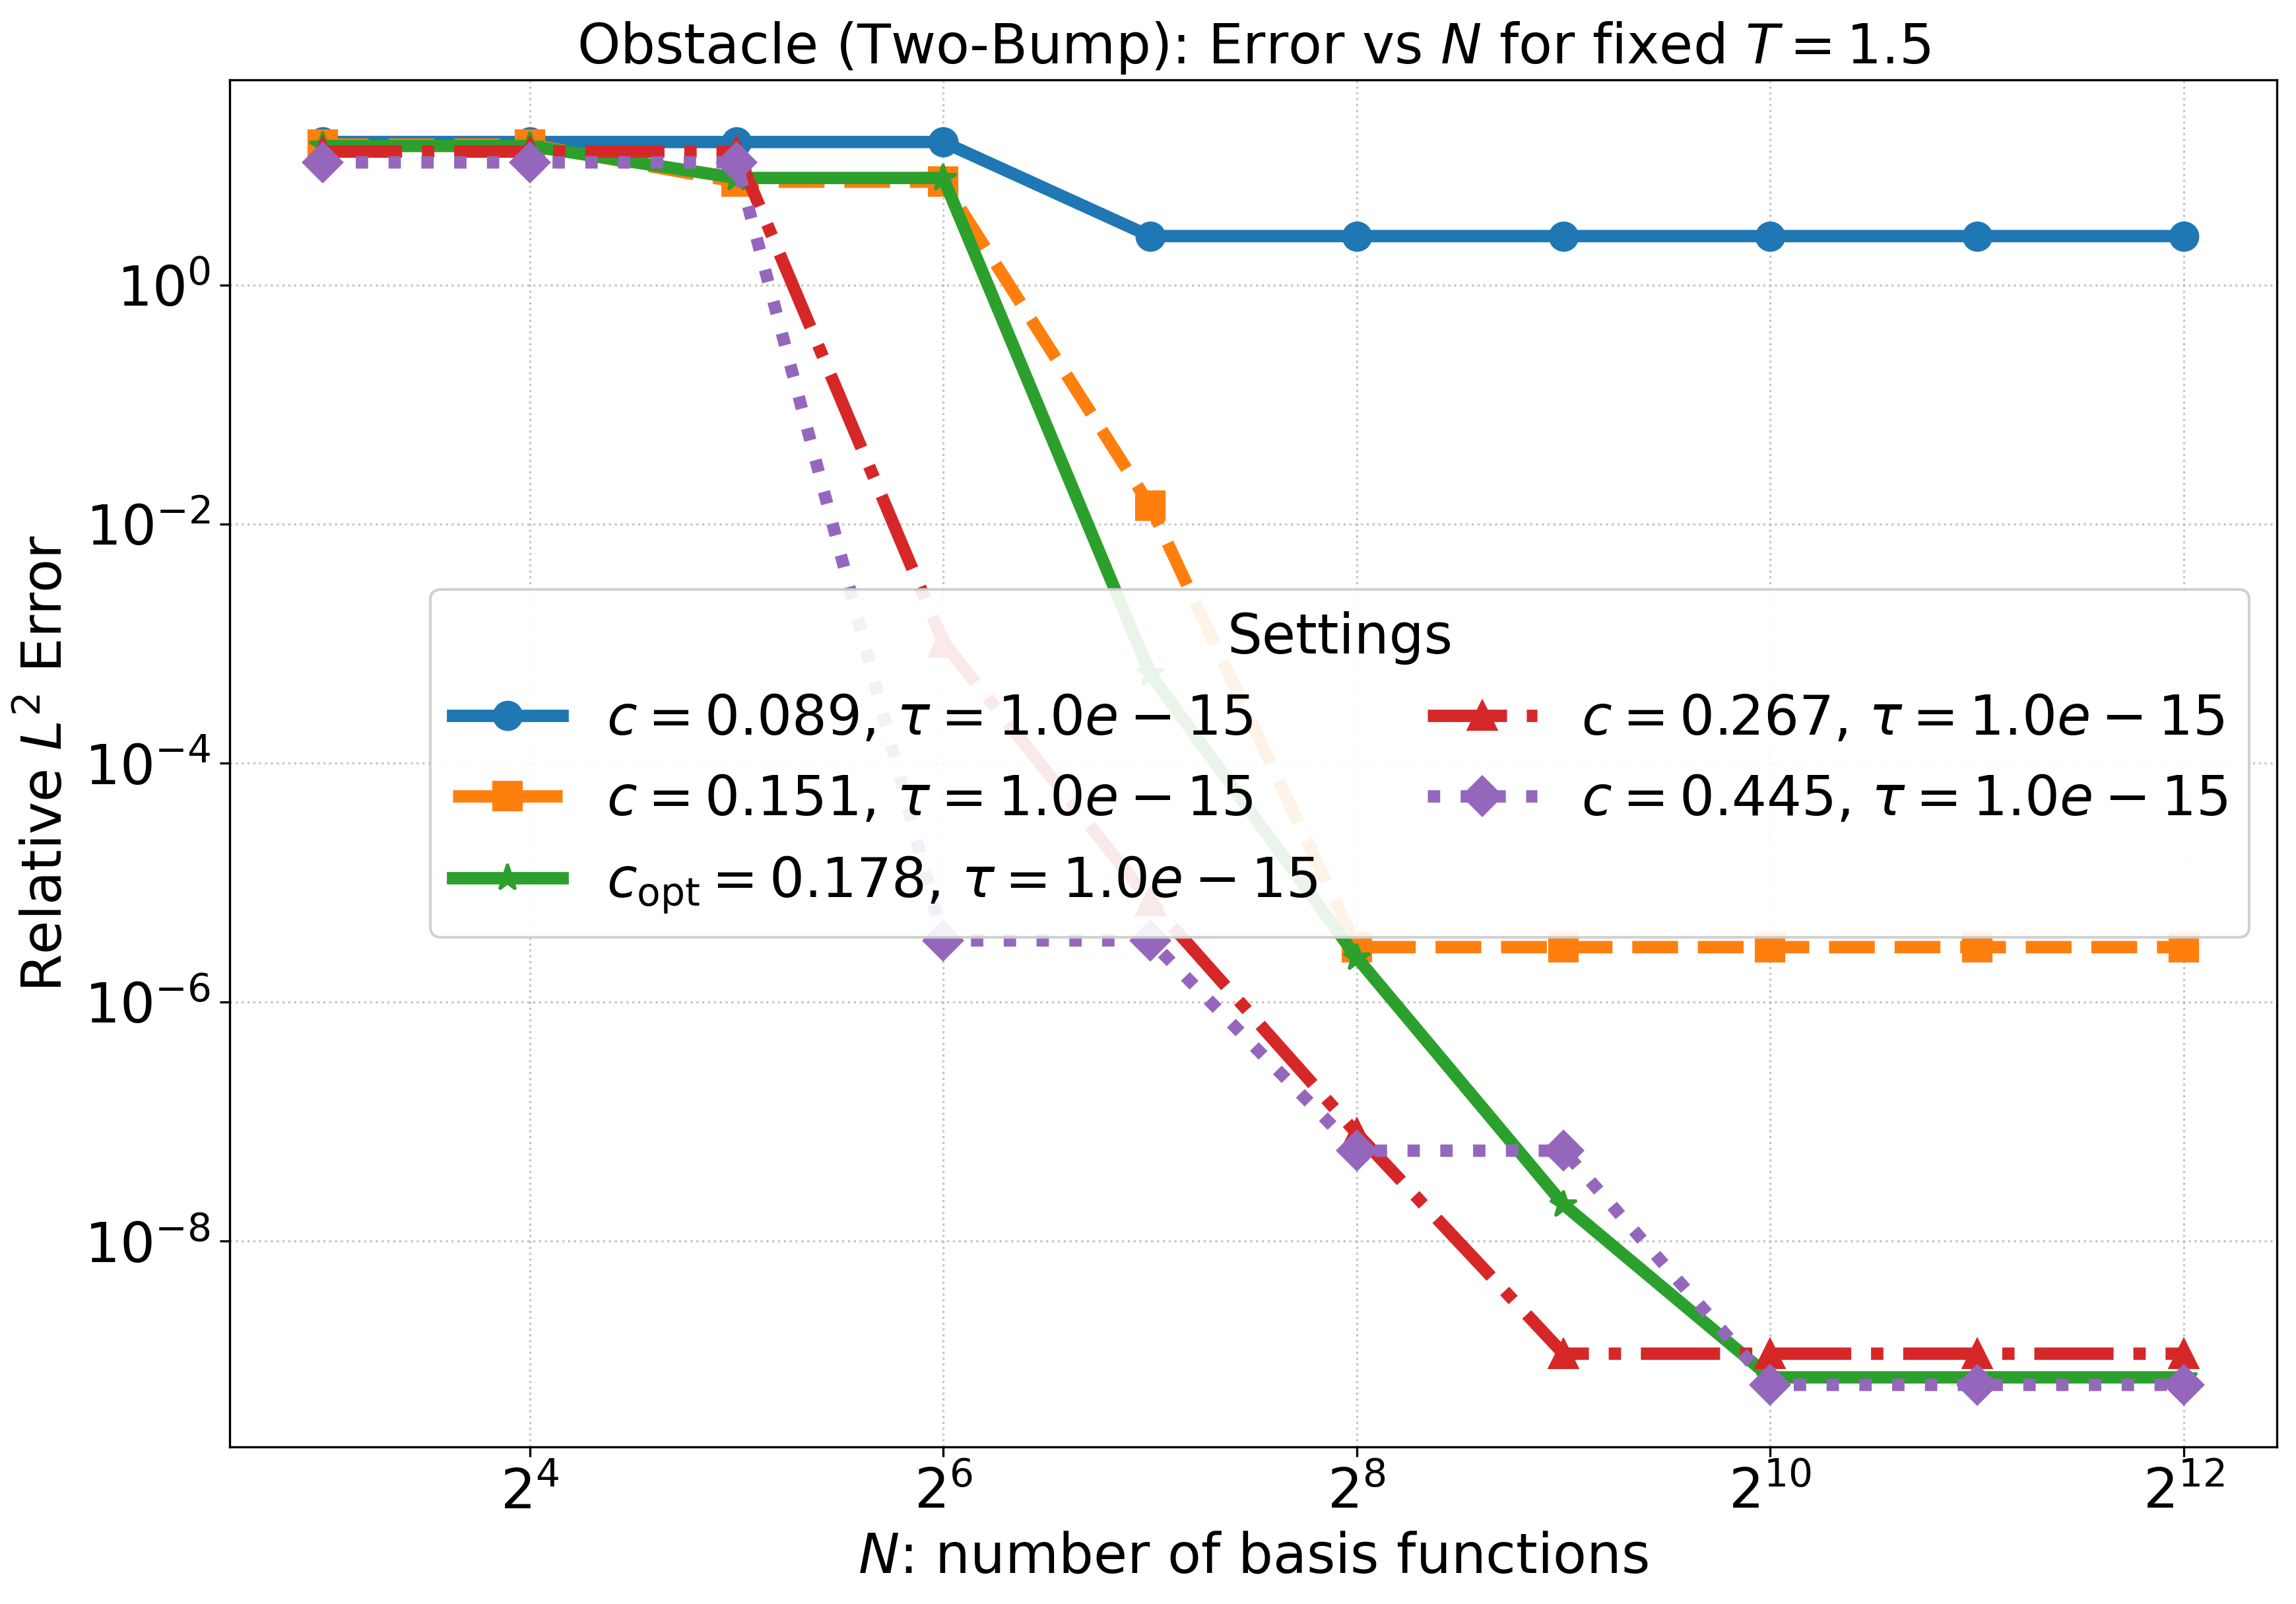

In [7]:
# =======================
# Fixed-T, varying-c experiment (Obstacle ADMM)
# =======================
import os, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from itertools import cycle

# Assumes:
# - solve_obstacle_rbf_admm(...) has the 'c_override' patch
# - rbf_obstacle_relL2_from_c(...) is defined as above

# ----------------------------
# Global plotting style (your rcParams)
# ----------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "legend.fontsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "lines.linewidth": 4.5,
    "lines.markersize": 20,
    "grid.alpha": 0.7,
    "figure.dpi": 300
})

# =======================
# Config
# =======================
problem        = "2"                 # "1" -> One-Bump, "2" -> Two-Bump
N_values       = np.array([8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096], dtype=int)
T_fixed        = 1.5                 # <-- FIXED T_kernel
tau_used       = 1e-15               # tau (must match solver)

# Helper: compute c(T) via your formula (optional utility)
def c_from_T(T, tau):
    # c = pi / (T * sqrt(2 * log(1 + tau^{-2})))
    return np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2))))

c_optim = c_from_T(T_fixed, tau_used)


c_values = np.asarray([0.089, 0.151, 0.267, 0.445, c_optim], dtype = float) # Problem 2
legend_ncols   = 2
EPS            = 1e-8                # clip for log-scale/printing

# Titles & output dirs per problem
title_map = {
    "1": rf"Obstacle (One-Bump): Error vs $N$ for fixed $T ={T_fixed}$",
    "2": rf"Obstacle (Two-Bump): Error vs $N$ for fixed $T ={T_fixed}$"
}
subdir_map = {"1": "Problem1", "2": "Problem2"}
base_dir   = "./Outputs/1D_Obstacle"
out_dir    = os.path.join(base_dir, subdir_map.get(problem, "Problem1"))
os.makedirs(out_dir, exist_ok=True)
N_values_plot = N_values
N_values = N_values//8
out_path   = os.path.join(out_dir, f"fig2_obstacle.png")

# =======================
# Run experiments
# =======================
E = {}       # c -> array of rel L2 error vs N
Times = {}   # c -> array of elapsed times vs N

print(f"Running fixed-T (T={T_fixed:g}), varying-c grid ...")
print("c values used: ", ", ".join(f"{c:.3f}" for c in c_values))

for c in c_values:
    errs, times = [], []
    print(f"\n[c = {c:.3f}]")
    for (N, N_plot) in zip(N_values, N_values_plot):
        t0 = time.perf_counter()
        rel_err, N_out, T_out, c_out = rbf_obstacle_relL2_from_c(
            N=N,
            c=float(c),
            T_kernel_fixed=T_fixed,
            T_cent = 1.0, 
            problem=problem,
            tau=tau_used,      # keep consistent with the solver
        )
        dt = time.perf_counter() - t0
        if (N_out != N) or (abs(T_out - T_fixed) > 1e-12) or (abs(c_out - c) > 1e-12):
            print(f"  [warn] returned (N={N_out}, T={T_out}, c={c_out}) "
                  f"for request (N={N}, T={T_fixed}, c={c})")
        errs.append(float(rel_err))
        times.append(float(dt))
        print(f"  N={N_plot:4d}  relL2={float(rel_err):.3e}  time={dt:.3f}s")
    E[float(c)]     = np.asarray(errs, dtype=float)
    Times[float(c)] = np.asarray(times, dtype=float)

# =======================
# Plot E(N) vs N for each c  (T fixed)
# =======================
marker_cycle    = cycle(['o', 's', '^', 'D', 'v', 'P', 'X', '*'])
linestyle_cycle = cycle(['-', '--', '-.', ':'])

fig, ax = plt.subplots(figsize=(12, 8.5), dpi=300)
for c in sorted(E.keys()):  # ordered legend
    y_raw = np.asarray(E[c], dtype=float)
    y = monotone_nonincreasing(y_raw, strict=True)
    #y = np.where(np.isfinite(y) & (y > 0.0), y, EPS)  # clip for log
    is_opt = abs(c - c_optim)<= 1e-15
    ax.plot(
        N_values_plot, y,
        marker=('*' if is_opt else next(marker_cycle)),
        linestyle=('-' if is_opt else next(linestyle_cycle)),
        linewidth = 4.5, 
        markersize=10,
        label = (rf"$c_\mathrm{{opt}} = {c_optim:.3f}$, $\tau = {tau_used:.1e}$" 
                 if is_opt else rf"$c={c:.3f}$, $\tau={tau_used:.1e}$")
    )

# Axes: log scales, with x-ticks exactly at N_values
ax.set_xscale('log', base=2)     # N doubles
ax.set_yscale('log')             # typical for errors

# Force ticks/labels to the exact N set
#ax.set_xticks(N_values)
#ax.set_xticklabels([str(n) for n in N_values])
#ax.tick_params(axis='x', which='major', width=2.0, length=10)
#ax.tick_params(axis='x', which='minor', bottom=False)  # hide minor x ticks
# Padding so end ticks aren’t cramped
#ax.set_xlim(N_values[0] * 0.95, N_values[-1] * 1.05)

ax.set_xlabel(r"$N$: number of basis functions")
ax.set_ylabel(r"Relative $L^2$ Error")
ax.set_title(title_map.get(problem, title_map["1"]))
ax.grid(True, which='both', linestyle=':')

leg = ax.legend(title="Settings", ncol=legend_ncols, frameon=True)
leg.get_frame().set_alpha(0.9)

fig.tight_layout()
fig.savefig(out_path)
# plt.show()

print(f"\nSaved plot to: {out_path}")

# ========== (Optional) quick best/worst summary ==========
for c in c_values:
    y = np.asarray(E[float(c)], dtype=float)
    j_best = np.nanargmin(y)
    best_val = max(y[j_best], EPS)
    print(f"c={c:.3f}: best relL2={best_val:.3e} at N={N_values[j_best]}")


Running fixed-T (T=2), varying-c grid ...
c values used:  0.089, 0.151, 0.267, 0.445, 0.134

[c = 0.089]
  N=   8  relL2=0.000e+00  time=0.002s
  N=  16  relL2=1.577e+01  time=0.016s
  N=  32  relL2=0.000e+00  time=0.010s
  N=  64  relL2=1.700e+01  time=0.018s
  N= 128  relL2=2.574e+00  time=0.021s
  N= 256  relL2=0.000e+00  time=0.015s
  N= 512  relL2=0.000e+00  time=0.026s
  N=1024  relL2=0.000e+00  time=0.104s
  N=2048  relL2=0.000e+00  time=0.498s
  N=4096  relL2=0.000e+00  time=1.193s

[c = 0.151]
  N=   8  relL2=0.000e+00  time=0.001s
  N=  16  relL2=1.503e+01  time=0.010s
  N=  32  relL2=7.335e+00  time=0.001s
  N=  64  relL2=0.000e+00  time=0.007s
  N= 128  relL2=1.431e-02  time=0.015s
  N= 256  relL2=2.892e-06  time=0.032s
  N= 512  relL2=0.000e+00  time=0.025s
  N=1024  relL2=0.000e+00  time=0.103s
  N=2048  relL2=0.000e+00  time=0.322s
  N=4096  relL2=0.000e+00  time=1.092s

[c = 0.267]
  N=   8  relL2=0.000e+00  time=0.004s
  N=  16  relL2=1.312e+01  time=0.012s
  N=  32  r

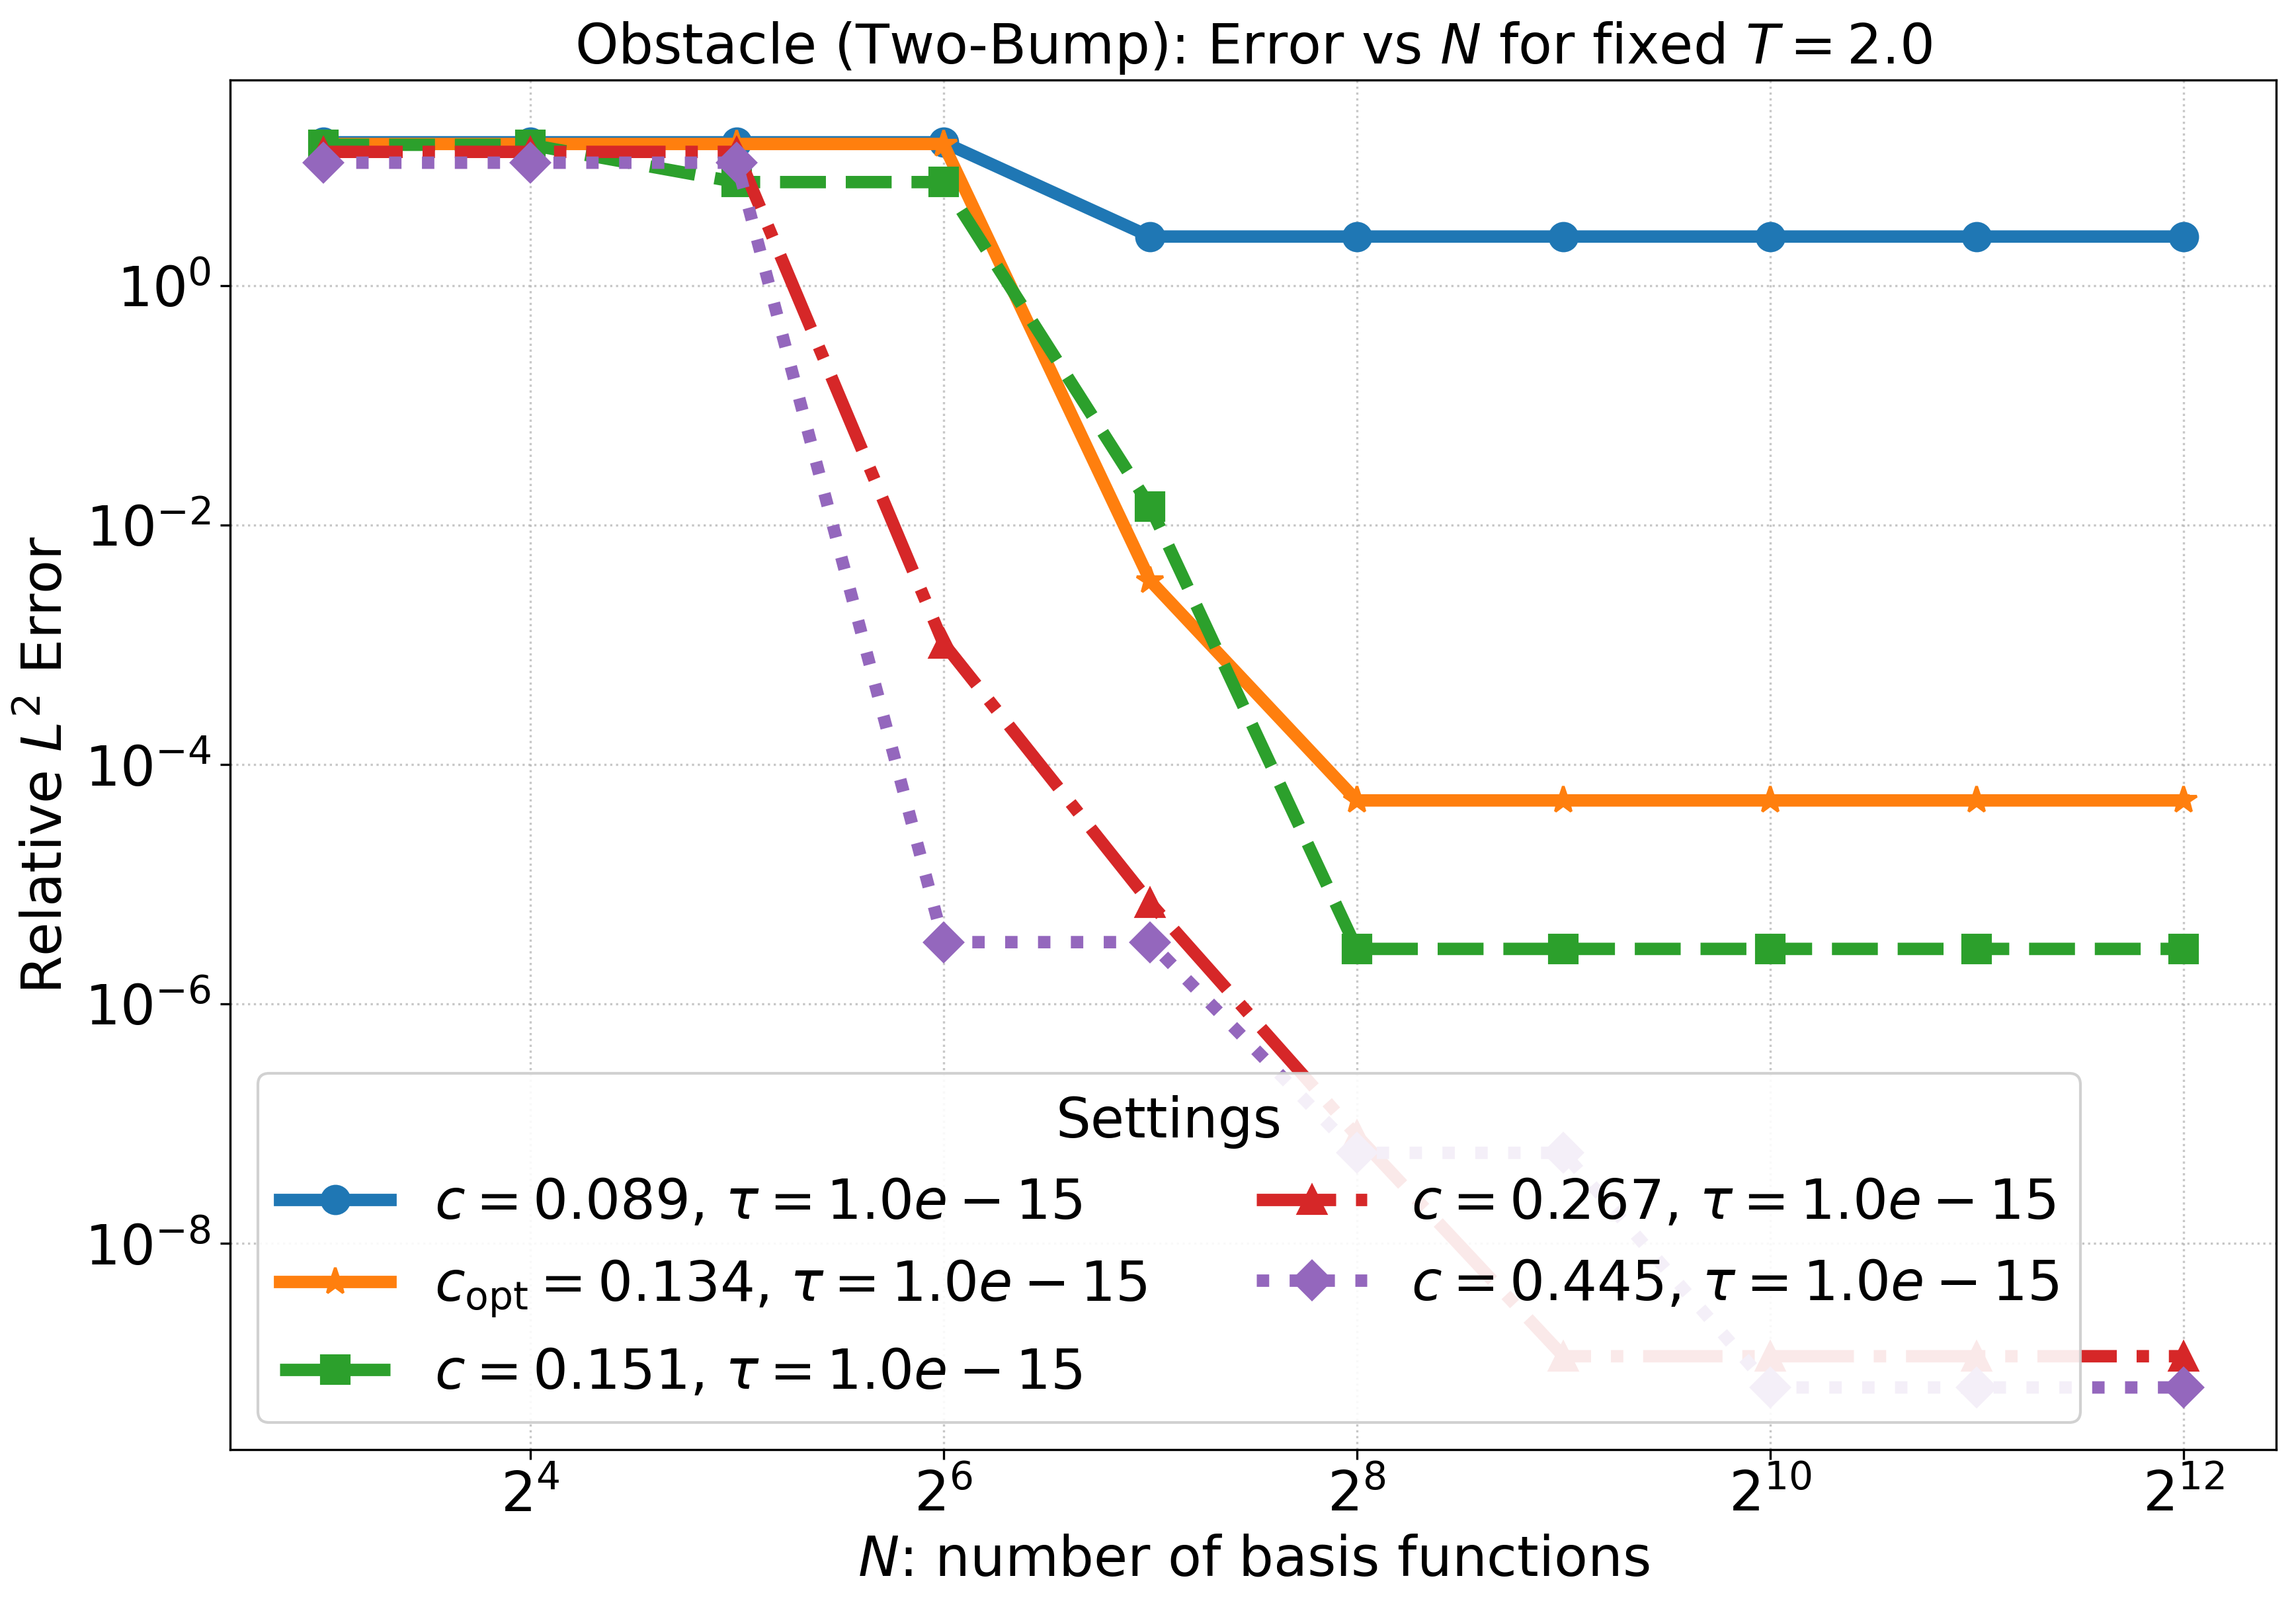

In [8]:
# =======================
# Fixed-T, varying-c experiment (Obstacle ADMM)
# =======================
import os, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from itertools import cycle

# Assumes:
# - solve_obstacle_rbf_admm(...) has the 'c_override' patch
# - rbf_obstacle_relL2_from_c(...) is defined as above

# ----------------------------
# Global plotting style (your rcParams)
# ----------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "legend.fontsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "lines.linewidth": 4.5,
    "lines.markersize": 20,
    "grid.alpha": 0.7,
    "figure.dpi": 300
})

# =======================
# Config
# =======================
problem        = "2"                 # "1" -> One-Bump, "2" -> Two-Bump
N_values       = np.array([8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096], dtype=int)
T_fixed        = 2.0                 # <-- FIXED T_kernel
tau_used       = 1e-15               # tau (must match solver)

# Helper: compute c(T) via your formula (optional utility)
def c_from_T(T, tau):
    # c = pi / (T * sqrt(2 * log(1 + tau^{-2})))
    return np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2))))

c_optim = c_from_T(T_fixed, tau_used)


c_values = np.asarray([0.089, 0.151, 0.267, 0.445, c_optim], dtype = float) # Problem 2
legend_ncols   = 2
EPS            = 1e-8                # clip for log-scale/printing

# Titles & output dirs per problem
title_map = {
    "1": rf"Obstacle (One-Bump): Error vs $N$ for fixed $T ={T_fixed}$",
    "2": rf"Obstacle (Two-Bump): Error vs $N$ for fixed $T ={T_fixed}$"
}
subdir_map = {"1": "Problem1", "2": "Problem2"}
base_dir   = "./Outputs/1D_Obstacle"
out_dir    = os.path.join(base_dir, subdir_map.get(problem, "Problem1"))
os.makedirs(out_dir, exist_ok=True)
N_values_plot = N_values
N_values = N_values//8
out_path   = os.path.join(out_dir, f"fig3_obstacle.png")

# =======================
# Run experiments
# =======================
E = {}       # c -> array of rel L2 error vs N
Times = {}   # c -> array of elapsed times vs N

print(f"Running fixed-T (T={T_fixed:g}), varying-c grid ...")
print("c values used: ", ", ".join(f"{c:.3f}" for c in c_values))

for c in c_values:
    errs, times = [], []
    print(f"\n[c = {c:.3f}]")
    for (N, N_plot) in zip(N_values, N_values_plot):
        t0 = time.perf_counter()
        rel_err, N_out, T_out, c_out = rbf_obstacle_relL2_from_c(
            N=N,
            c=float(c),
            T_kernel_fixed=T_fixed,
            T_cent = 1.0, 
            problem=problem,
            tau=tau_used,      # keep consistent with the solver
        )
        dt = time.perf_counter() - t0
        if (N_out != N) or (abs(T_out - T_fixed) > 1e-12) or (abs(c_out - c) > 1e-12):
            print(f"  [warn] returned (N={N_out}, T={T_out}, c={c_out}) "
                  f"for request (N={N}, T={T_fixed}, c={c})")
        errs.append(float(rel_err))
        times.append(float(dt))
        print(f"  N={N_plot:4d}  relL2={float(rel_err):.3e}  time={dt:.3f}s")
    E[float(c)]     = np.asarray(errs, dtype=float)
    Times[float(c)] = np.asarray(times, dtype=float)

# =======================
# Plot E(N) vs N for each c  (T fixed)
# =======================
marker_cycle    = cycle(['o', 's', '^', 'D', 'v', 'P', 'X', '*'])
linestyle_cycle = cycle(['-', '--', '-.', ':'])

fig, ax = plt.subplots(figsize=(12, 8.5), dpi=300)
for c in sorted(E.keys()):  # ordered legend
    y_raw = np.asarray(E[c], dtype=float)
    y = monotone_nonincreasing(y_raw, strict=True)
    #y = np.where(np.isfinite(y) & (y > 0.0), y, EPS)  # clip for log
    is_opt = abs(c - c_optim)<= 1e-15
    ax.plot(
        N_values_plot, y,
        marker=('*' if is_opt else next(marker_cycle)),
        linestyle=('-' if is_opt else next(linestyle_cycle)),
        linewidth = 4.5, 
        markersize=10,
        label = (rf"$c_\mathrm{{opt}} = {c_optim:.3f}$, $\tau = {tau_used:.1e}$" 
                 if is_opt else rf"$c={c:.3f}$, $\tau={tau_used:.1e}$")
    )

# Axes: log scales, with x-ticks exactly at N_values
ax.set_xscale('log', base=2)     # N doubles
ax.set_yscale('log')             # typical for errors

# Force ticks/labels to the exact N set
#ax.set_xticks(N_values)
#ax.set_xticklabels([str(n) for n in N_values])
#ax.tick_params(axis='x', which='major', width=2.0, length=10)
#ax.tick_params(axis='x', which='minor', bottom=False)  # hide minor x ticks
# Padding so end ticks aren’t cramped
#ax.set_xlim(N_values[0] * 0.95, N_values[-1] * 1.05)

ax.set_xlabel(r"$N$: number of basis functions")
ax.set_ylabel(r"Relative $L^2$ Error")
ax.set_title(title_map.get(problem, title_map["1"]))
ax.grid(True, which='both', linestyle=':')

leg = ax.legend(title="Settings", ncol=legend_ncols, frameon=True)
leg.get_frame().set_alpha(0.9)

fig.tight_layout()
fig.savefig(out_path)
# plt.show()

print(f"\nSaved plot to: {out_path}")

# ========== (Optional) quick best/worst summary ==========
for c in c_values:
    y = np.asarray(E[float(c)], dtype=float)
    j_best = np.nanargmin(y)
    best_val = max(y[j_best], EPS)
    print(f"c={c:.3f}: best relL2={best_val:.3e} at N={N_values[j_best]}")


Running fixed-T (T=4), varying-c grid ...
c values used:  0.089, 0.151, 0.267, 0.445, 0.067

[c = 0.089]
  N=   8  relL2=0.000e+00  time=0.006s
  N=  16  relL2=1.577e+01  time=0.013s
  N=  32  relL2=0.000e+00  time=0.008s
  N=  64  relL2=1.700e+01  time=0.017s
  N= 128  relL2=2.574e+00  time=0.023s
  N= 256  relL2=0.000e+00  time=0.017s
  N= 512  relL2=0.000e+00  time=0.027s
  N=1024  relL2=0.000e+00  time=0.091s
  N=2048  relL2=0.000e+00  time=0.460s
  N=4096  relL2=0.000e+00  time=1.172s

[c = 0.151]
  N=   8  relL2=0.000e+00  time=0.001s
  N=  16  relL2=1.503e+01  time=0.010s
  N=  32  relL2=7.335e+00  time=0.001s
  N=  64  relL2=0.000e+00  time=0.007s
  N= 128  relL2=1.431e-02  time=0.013s
  N= 256  relL2=2.892e-06  time=0.033s
  N= 512  relL2=0.000e+00  time=0.026s
  N=1024  relL2=0.000e+00  time=0.102s
  N=2048  relL2=0.000e+00  time=0.314s
  N=4096  relL2=0.000e+00  time=1.084s

[c = 0.267]
  N=   8  relL2=0.000e+00  time=0.006s
  N=  16  relL2=1.312e+01  time=0.010s
  N=  32  r

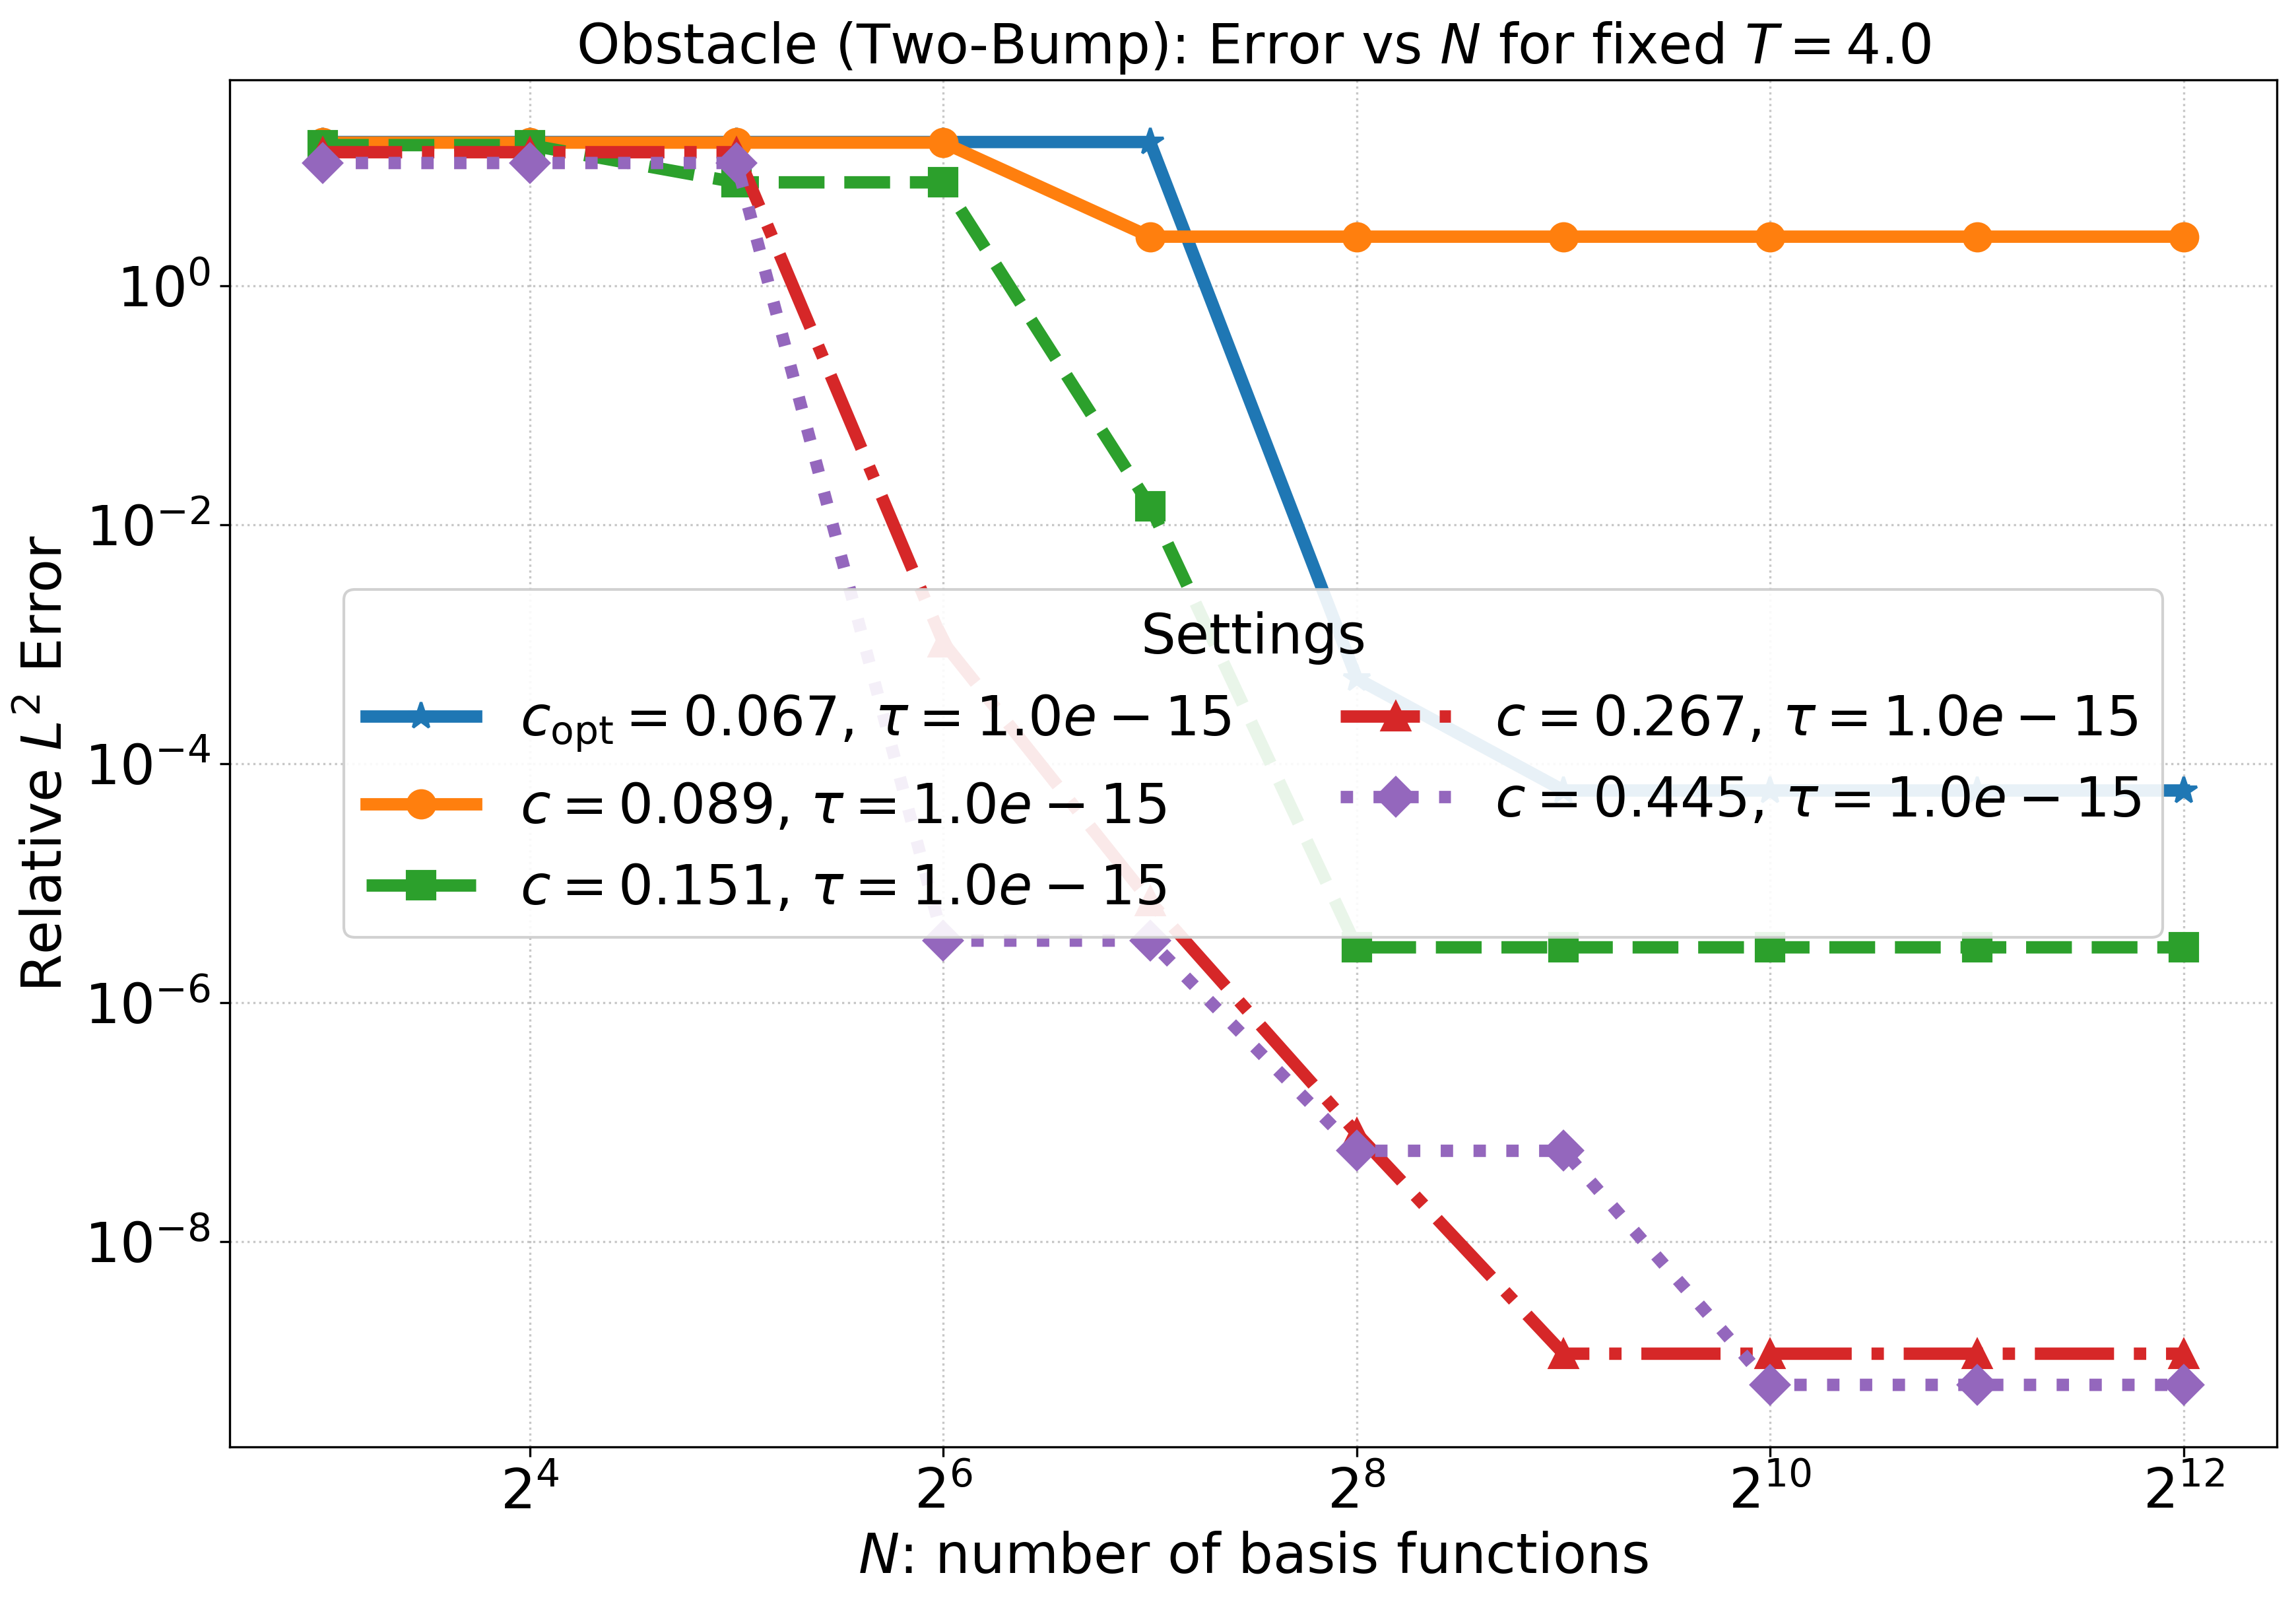

In [10]:
# =======================
# Fixed-T, varying-c experiment (Obstacle ADMM)
# =======================
import os, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from itertools import cycle

# Assumes:
# - solve_obstacle_rbf_admm(...) has the 'c_override' patch
# - rbf_obstacle_relL2_from_c(...) is defined as above

# ----------------------------
# Global plotting style (your rcParams)
# ----------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "legend.fontsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "lines.linewidth": 4.5,
    "lines.markersize": 20,
    "grid.alpha": 0.7,
    "figure.dpi": 300
})

# =======================
# Config
# =======================
problem        = "2"                 # "1" -> One-Bump, "2" -> Two-Bump
N_values       = np.array([8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096], dtype=int)
T_fixed        = 4.0                # <-- FIXED T_kernel
tau_used       = 1e-15               # tau (must match solver)

# Helper: compute c(T) via your formula (optional utility)
def c_from_T(T, tau):
    # c = pi / (T * sqrt(2 * log(1 + tau^{-2})))
    return np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2))))

c_optim = c_from_T(T_fixed, tau_used)


c_values = np.asarray([0.089, 0.151, 0.267, 0.445, c_optim], dtype = float) # Problem 2
legend_ncols   = 2
EPS            = 1e-8                # clip for log-scale/printing

# Titles & output dirs per problem
title_map = {
    "1": rf"Obstacle (One-Bump): Error vs $N$ for fixed $T ={T_fixed}$",
    "2": rf"Obstacle (Two-Bump): Error vs $N$ for fixed $T ={T_fixed}$"
}
subdir_map = {"1": "Problem1", "2": "Problem2"}
base_dir   = "./Outputs/1D_Obstacle"
out_dir    = os.path.join(base_dir, subdir_map.get(problem, "Problem1"))
os.makedirs(out_dir, exist_ok=True)
N_values_plot = N_values
N_values = N_values//8
out_path   = os.path.join(out_dir, f"fig4_obstacle.png")

# =======================
# Run experiments
# =======================
E = {}       # c -> array of rel L2 error vs N
Times = {}   # c -> array of elapsed times vs N

print(f"Running fixed-T (T={T_fixed:g}), varying-c grid ...")
print("c values used: ", ", ".join(f"{c:.3f}" for c in c_values))

for c in c_values:
    errs, times = [], []
    print(f"\n[c = {c:.3f}]")
    for (N, N_plot) in zip(N_values, N_values_plot):
        t0 = time.perf_counter()
        rel_err, N_out, T_out, c_out = rbf_obstacle_relL2_from_c(
            N=N,
            c=float(c),
            T_kernel_fixed=T_fixed,
            T_cent = 1.0, 
            problem=problem,
            tau=tau_used,      # keep consistent with the solver
        )
        dt = time.perf_counter() - t0
        if (N_out != N) or (abs(T_out - T_fixed) > 1e-12) or (abs(c_out - c) > 1e-12):
            print(f"  [warn] returned (N={N_out}, T={T_out}, c={c_out}) "
                  f"for request (N={N}, T={T_fixed}, c={c})")
        errs.append(float(rel_err))
        times.append(float(dt))
        print(f"  N={N_plot:4d}  relL2={float(rel_err):.3e}  time={dt:.3f}s")
    E[float(c)]     = np.asarray(errs, dtype=float)
    Times[float(c)] = np.asarray(times, dtype=float)

# =======================
# Plot E(N) vs N for each c  (T fixed)
# =======================
marker_cycle    = cycle(['o', 's', '^', 'D', 'v', 'P', 'X', '*'])
linestyle_cycle = cycle(['-', '--', '-.', ':'])

fig, ax = plt.subplots(figsize=(12, 8.5), dpi=300)
for c in sorted(E.keys()):  # ordered legend
    y_raw = np.asarray(E[c], dtype=float)
    y = monotone_nonincreasing(y_raw, strict=True)
    #y = np.where(np.isfinite(y) & (y > 0.0), y, EPS)  # clip for log
    is_opt = abs(c - c_optim)<= 1e-15
    ax.plot(
        N_values_plot, y,
        marker=('*' if is_opt else next(marker_cycle)),
        linestyle=('-' if is_opt else next(linestyle_cycle)),
        linewidth = 4.5, 
        markersize=10,
        label = (rf"$c_\mathrm{{opt}} = {c_optim:.3f}$, $\tau = {tau_used:.1e}$" 
                 if is_opt else rf"$c={c:.3f}$, $\tau={tau_used:.1e}$")
    )

# Axes: log scales, with x-ticks exactly at N_values
ax.set_xscale('log', base=2)     # N doubles
ax.set_yscale('log')             # typical for errors

# Force ticks/labels to the exact N set
#ax.set_xticks(N_values)
#ax.set_xticklabels([str(n) for n in N_values])
#ax.tick_params(axis='x', which='major', width=2.0, length=10)
#ax.tick_params(axis='x', which='minor', bottom=False)  # hide minor x ticks
# Padding so end ticks aren’t cramped
#ax.set_xlim(N_values[0] * 0.95, N_values[-1] * 1.05)

ax.set_xlabel(r"$N$: number of basis functions")
ax.set_ylabel(r"Relative $L^2$ Error")
ax.set_title(title_map.get(problem, title_map["1"]))
ax.grid(True, which='both', linestyle=':')

leg = ax.legend(title="Settings", ncol=legend_ncols, frameon=True, loc = 'center')
leg.get_frame().set_alpha(0.9)

fig.tight_layout()
fig.savefig(out_path)
# plt.show()

print(f"\nSaved plot to: {out_path}")

# ========== (Optional) quick best/worst summary ==========
for c in c_values:
    y = np.asarray(E[float(c)], dtype=float)
    j_best = np.nanargmin(y)
    best_val = max(y[j_best], EPS)
    print(f"c={c:.3f}: best relL2={best_val:.3e} at N={N_values[j_best]}")


Running fixed-T (T=6), varying-c grid ...
c values used:  0.089, 0.151, 0.267, 0.445, 0.045

[c = 0.089]
  N=   8  relL2=0.000e+00  time=0.004s
  N=  16  relL2=1.577e+01  time=0.022s
  N=  32  relL2=0.000e+00  time=0.011s
  N=  64  relL2=1.700e+01  time=0.018s
  N= 128  relL2=2.574e+00  time=0.021s
  N= 256  relL2=0.000e+00  time=0.015s
  N= 512  relL2=0.000e+00  time=0.027s
  N=1024  relL2=0.000e+00  time=0.110s
  N=2048  relL2=0.000e+00  time=0.498s
  N=4096  relL2=0.000e+00  time=1.257s

[c = 0.151]
  N=   8  relL2=0.000e+00  time=0.002s
  N=  16  relL2=1.503e+01  time=0.010s
  N=  32  relL2=7.335e+00  time=0.001s
  N=  64  relL2=0.000e+00  time=0.007s
  N= 128  relL2=1.431e-02  time=0.013s
  N= 256  relL2=2.892e-06  time=0.033s
  N= 512  relL2=0.000e+00  time=0.026s
  N=1024  relL2=0.000e+00  time=0.109s
  N=2048  relL2=0.000e+00  time=0.322s
  N=4096  relL2=0.000e+00  time=1.135s

[c = 0.267]
  N=   8  relL2=0.000e+00  time=0.003s
  N=  16  relL2=1.312e+01  time=0.010s
  N=  32  r

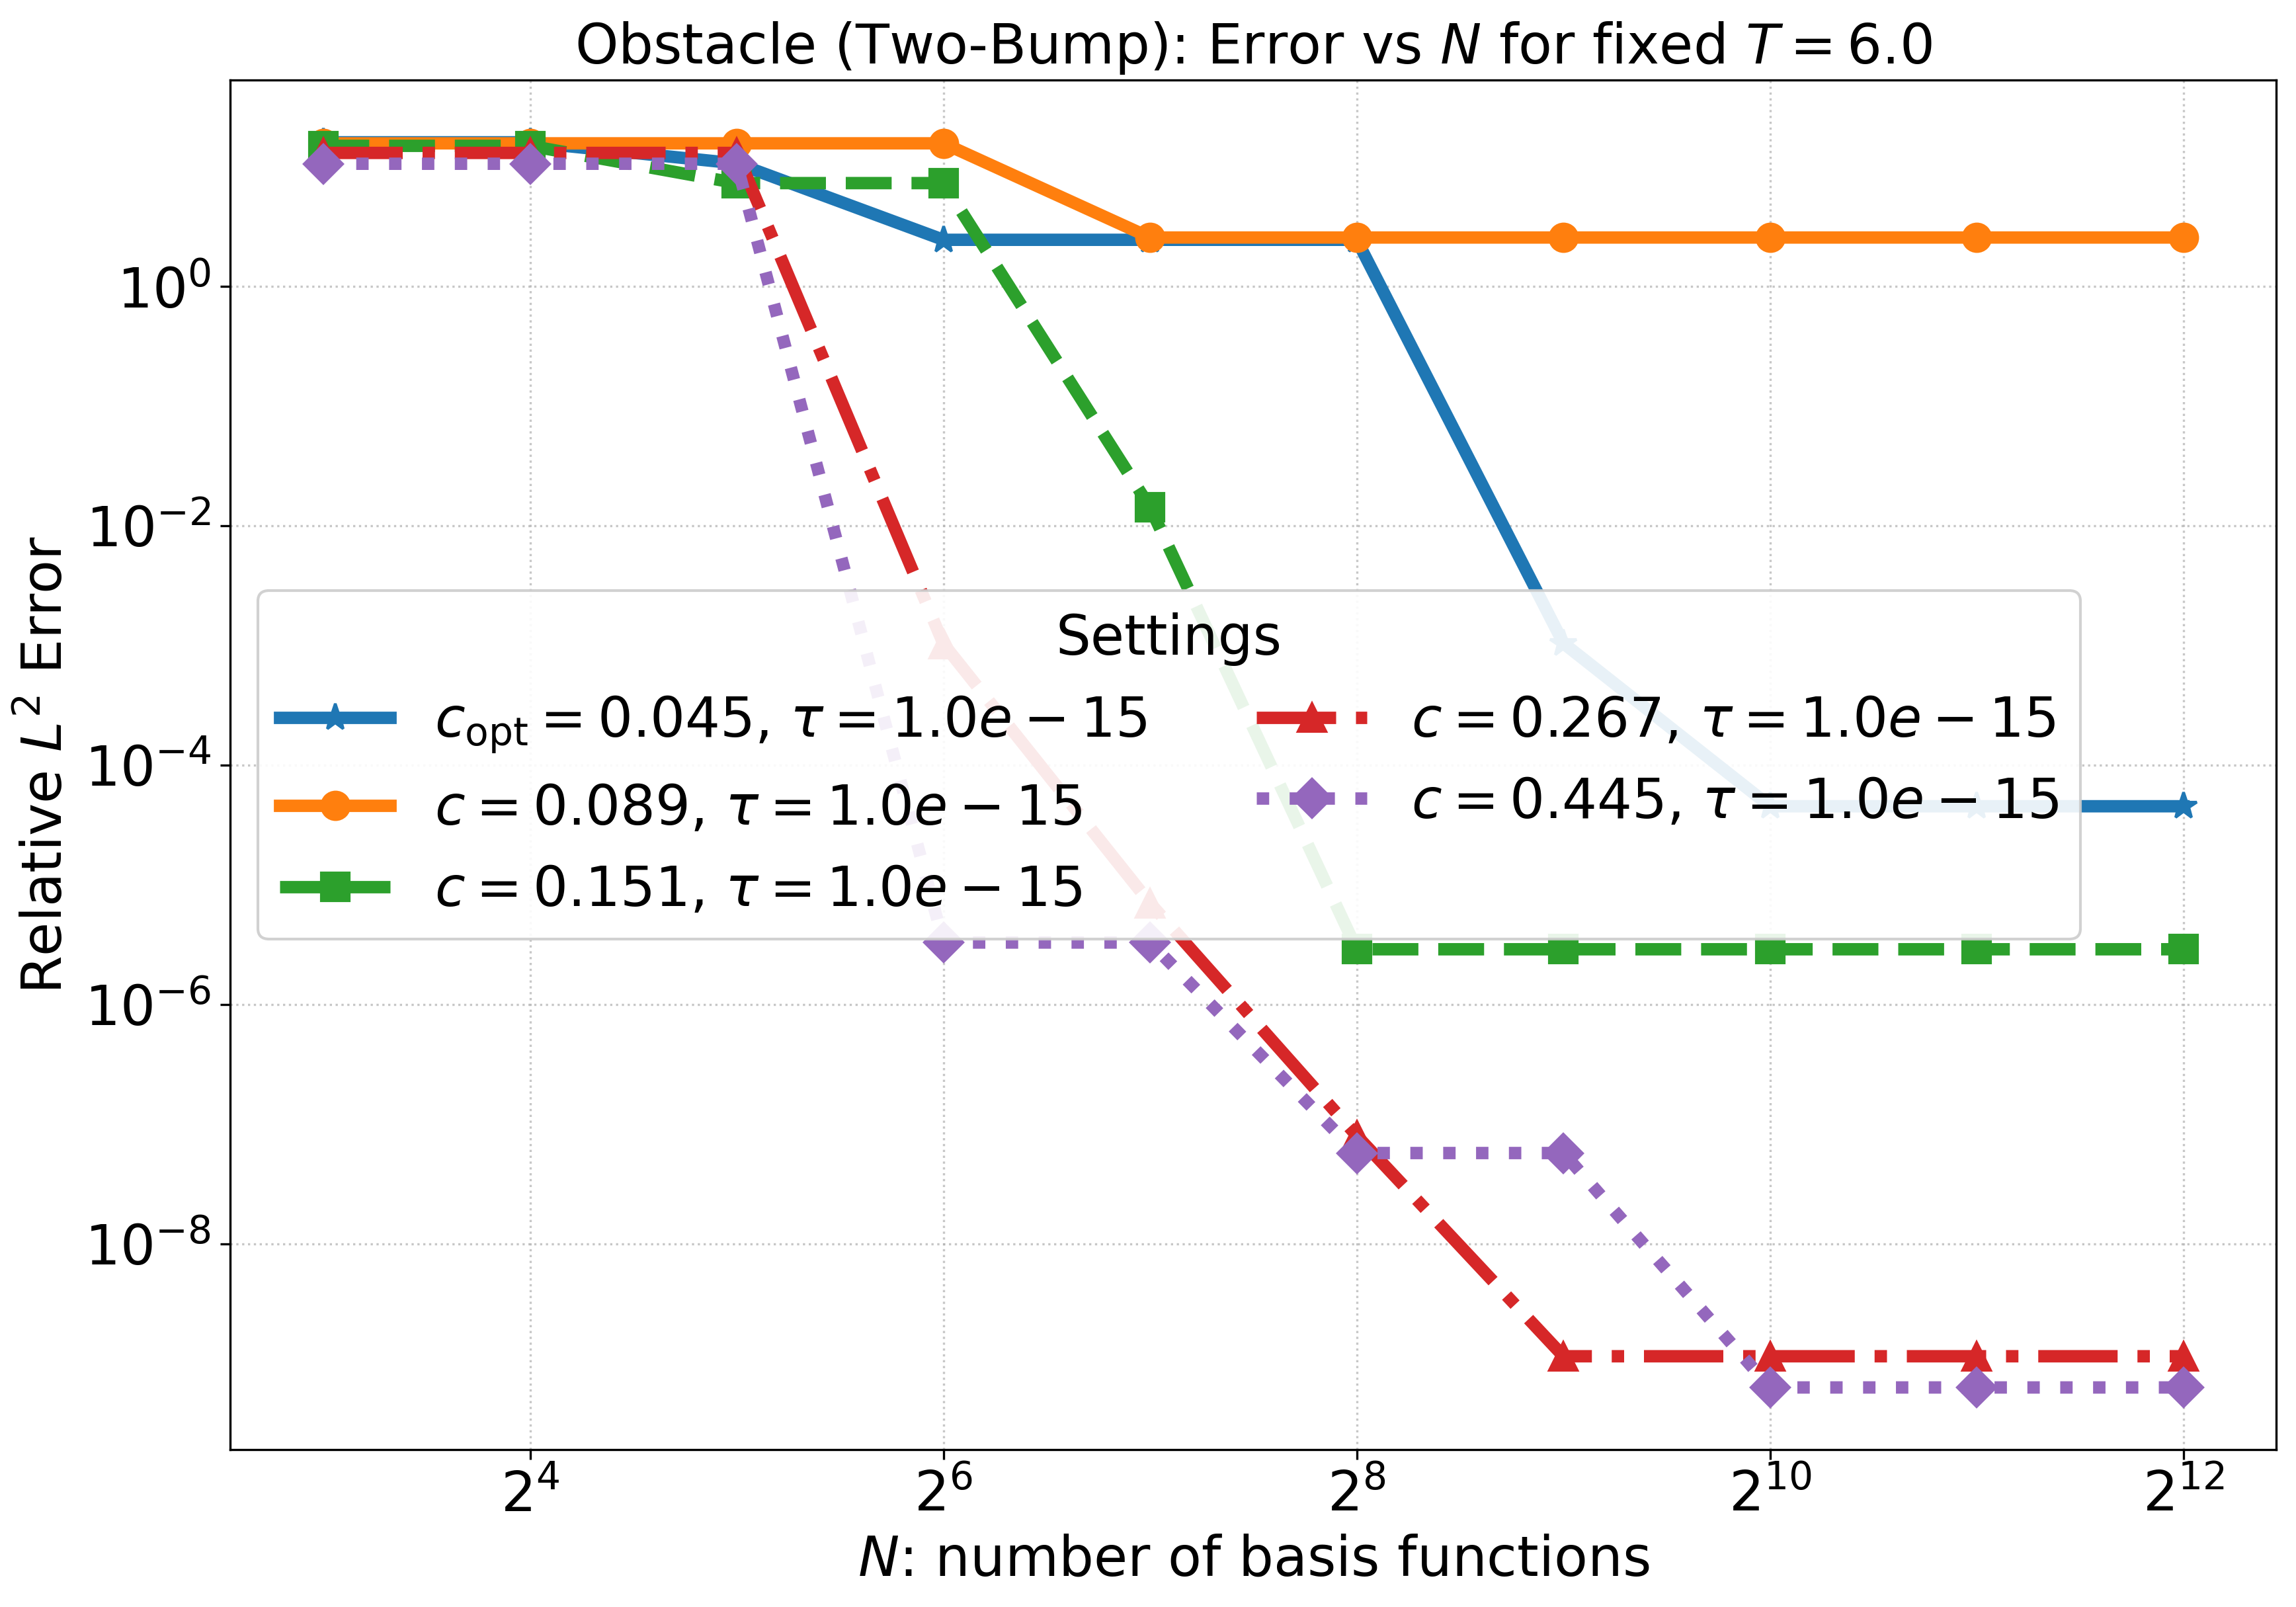

In [11]:
# =======================
# Fixed-T, varying-c experiment (Obstacle ADMM)
# =======================
import os, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from itertools import cycle

# Assumes:
# - solve_obstacle_rbf_admm(...) has the 'c_override' patch
# - rbf_obstacle_relL2_from_c(...) is defined as above

# ----------------------------
# Global plotting style (your rcParams)
# ----------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "legend.fontsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "lines.linewidth": 4.5,
    "lines.markersize": 20,
    "grid.alpha": 0.7,
    "figure.dpi": 300
})

# =======================
# Config
# =======================
problem        = "2"                 # "1" -> One-Bump, "2" -> Two-Bump
N_values       = np.array([8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096], dtype=int)
T_fixed        = 6.0                 # <-- FIXED T_kernel
tau_used       = 1e-15               # tau (must match solver)

# Helper: compute c(T) via your formula (optional utility)
def c_from_T(T, tau):
    # c = pi / (T * sqrt(2 * log(1 + tau^{-2})))
    return np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2))))

c_optim = c_from_T(T_fixed, tau_used)


c_values = np.asarray([0.089, 0.151, 0.267, 0.445, c_optim], dtype = float) # Problem 2
legend_ncols   = 2
EPS            = 1e-8                # clip for log-scale/printing

# Titles & output dirs per problem
title_map = {
    "1": rf"Obstacle (One-Bump): Error vs $N$ for fixed $T ={T_fixed}$",
    "2": rf"Obstacle (Two-Bump): Error vs $N$ for fixed $T ={T_fixed}$"
}
subdir_map = {"1": "Problem1", "2": "Problem2"}
base_dir   = "./Outputs/1D_Obstacle"
out_dir    = os.path.join(base_dir, subdir_map.get(problem, "Problem1"))
os.makedirs(out_dir, exist_ok=True)
N_values_plot = N_values
N_values = N_values//8
out_path   = os.path.join(out_dir, f"fig5_obstacle.png")

# =======================
# Run experiments
# =======================
E = {}       # c -> array of rel L2 error vs N
Times = {}   # c -> array of elapsed times vs N

print(f"Running fixed-T (T={T_fixed:g}), varying-c grid ...")
print("c values used: ", ", ".join(f"{c:.3f}" for c in c_values))

for c in c_values:
    errs, times = [], []
    print(f"\n[c = {c:.3f}]")
    for (N, N_plot) in zip(N_values, N_values_plot):
        t0 = time.perf_counter()
        rel_err, N_out, T_out, c_out = rbf_obstacle_relL2_from_c(
            N=N,
            c=float(c),
            T_kernel_fixed=T_fixed,
            T_cent = 1.0, 
            problem=problem,
            tau=tau_used,      # keep consistent with the solver
        )
        dt = time.perf_counter() - t0
        if (N_out != N) or (abs(T_out - T_fixed) > 1e-12) or (abs(c_out - c) > 1e-12):
            print(f"  [warn] returned (N={N_out}, T={T_out}, c={c_out}) "
                  f"for request (N={N}, T={T_fixed}, c={c})")
        errs.append(float(rel_err))
        times.append(float(dt))
        print(f"  N={N_plot:4d}  relL2={float(rel_err):.3e}  time={dt:.3f}s")
    E[float(c)]     = np.asarray(errs, dtype=float)
    Times[float(c)] = np.asarray(times, dtype=float)

# =======================
# Plot E(N) vs N for each c  (T fixed)
# =======================
marker_cycle    = cycle(['o', 's', '^', 'D', 'v', 'P', 'X', '*'])
linestyle_cycle = cycle(['-', '--', '-.', ':'])

fig, ax = plt.subplots(figsize=(12, 8.5), dpi=300)
for c in sorted(E.keys()):  # ordered legend
    y_raw = np.asarray(E[c], dtype=float)
    y = monotone_nonincreasing(y_raw, strict=True)
    #y = np.where(np.isfinite(y) & (y > 0.0), y, EPS)  # clip for log
    is_opt = abs(c - c_optim)<= 1e-15
    ax.plot(
        N_values_plot, y,
        marker=('*' if is_opt else next(marker_cycle)),
        linestyle=('-' if is_opt else next(linestyle_cycle)),
        linewidth = 4.5, 
        markersize=10,
        label = (rf"$c_\mathrm{{opt}} = {c_optim:.3f}$, $\tau = {tau_used:.1e}$" 
                 if is_opt else rf"$c={c:.3f}$, $\tau={tau_used:.1e}$")
    )

# Axes: log scales, with x-ticks exactly at N_values
ax.set_xscale('log', base=2)     # N doubles
ax.set_yscale('log')             # typical for errors

# Force ticks/labels to the exact N set
#ax.set_xticks(N_values)
#ax.set_xticklabels([str(n) for n in N_values])
#ax.tick_params(axis='x', which='major', width=2.0, length=10)
#ax.tick_params(axis='x', which='minor', bottom=False)  # hide minor x ticks
# Padding so end ticks aren’t cramped
#ax.set_xlim(N_values[0] * 0.95, N_values[-1] * 1.05)

ax.set_xlabel(r"$N$: number of basis functions")
ax.set_ylabel(r"Relative $L^2$ Error")
ax.set_title(title_map.get(problem, title_map["1"]))
ax.grid(True, which='both', linestyle=':')

leg = ax.legend(title="Settings", ncol=legend_ncols, frameon=True)
leg.get_frame().set_alpha(0.9)

fig.tight_layout()
fig.savefig(out_path)
# plt.show()

print(f"\nSaved plot to: {out_path}")

# ========== (Optional) quick best/worst summary ==========
for c in c_values:
    y = np.asarray(E[float(c)], dtype=float)
    j_best = np.nanargmin(y)
    best_val = max(y[j_best], EPS)
    print(f"c={c:.3f}: best relL2={best_val:.3e} at N={N_values[j_best]}")


# Benchmark for fixed value T and threshold value $\tau$

Running fixed-T (T=1.5), varying-τ grid ...
τ and c(T,τ) values:
  tau= 1.0e-03  c=0.398437
  tau= 1.0e-06  c=0.281738
  tau= 1.0e-09  c=0.230038
  tau= 1.0e-12  c=0.199219
  tau= 1.0e-15  c=0.178187

[ tau = 1.0e-03, c(T,τ)=0.398437 ]
  N=   8  relL2=0.000e+00  time=0.007s
  N=  16  relL2=1.111e+01  time=0.012s
  N=  32  relL2=3.924e+01  time=0.002s
  N=  64  relL2=1.888e+03  time=0.004s
  N= 128  relL2=2.877e-02  time=0.006s
  N= 256  relL2=3.909e-04  time=0.053s
  N= 512  relL2=2.152e-06  time=0.348s
  N=1024  relL2=4.891e-09  time=1.457s
  N=2048  relL2=5.844e-09  time=6.908s
  N=4096  relL2=2.303e-07  time=33.664s

[ tau = 1.0e-06, c(T,τ)=0.281738 ]
  N=   8  relL2=0.000e+00  time=0.005s
  N=  16  relL2=1.286e+01  time=0.012s
  N=  32  relL2=1.647e+01  time=0.002s
  N=  64  relL2=8.694e-04  time=0.004s
  N= 128  relL2=7.175e-05  time=0.009s
  N= 256  relL2=1.400e-07  time=0.041s
  N= 512  relL2=5.871e-09  time=0.402s
  N=1024  relL2=6.678e-10  time=1.618s
  N=2048  relL2=5.699e-09

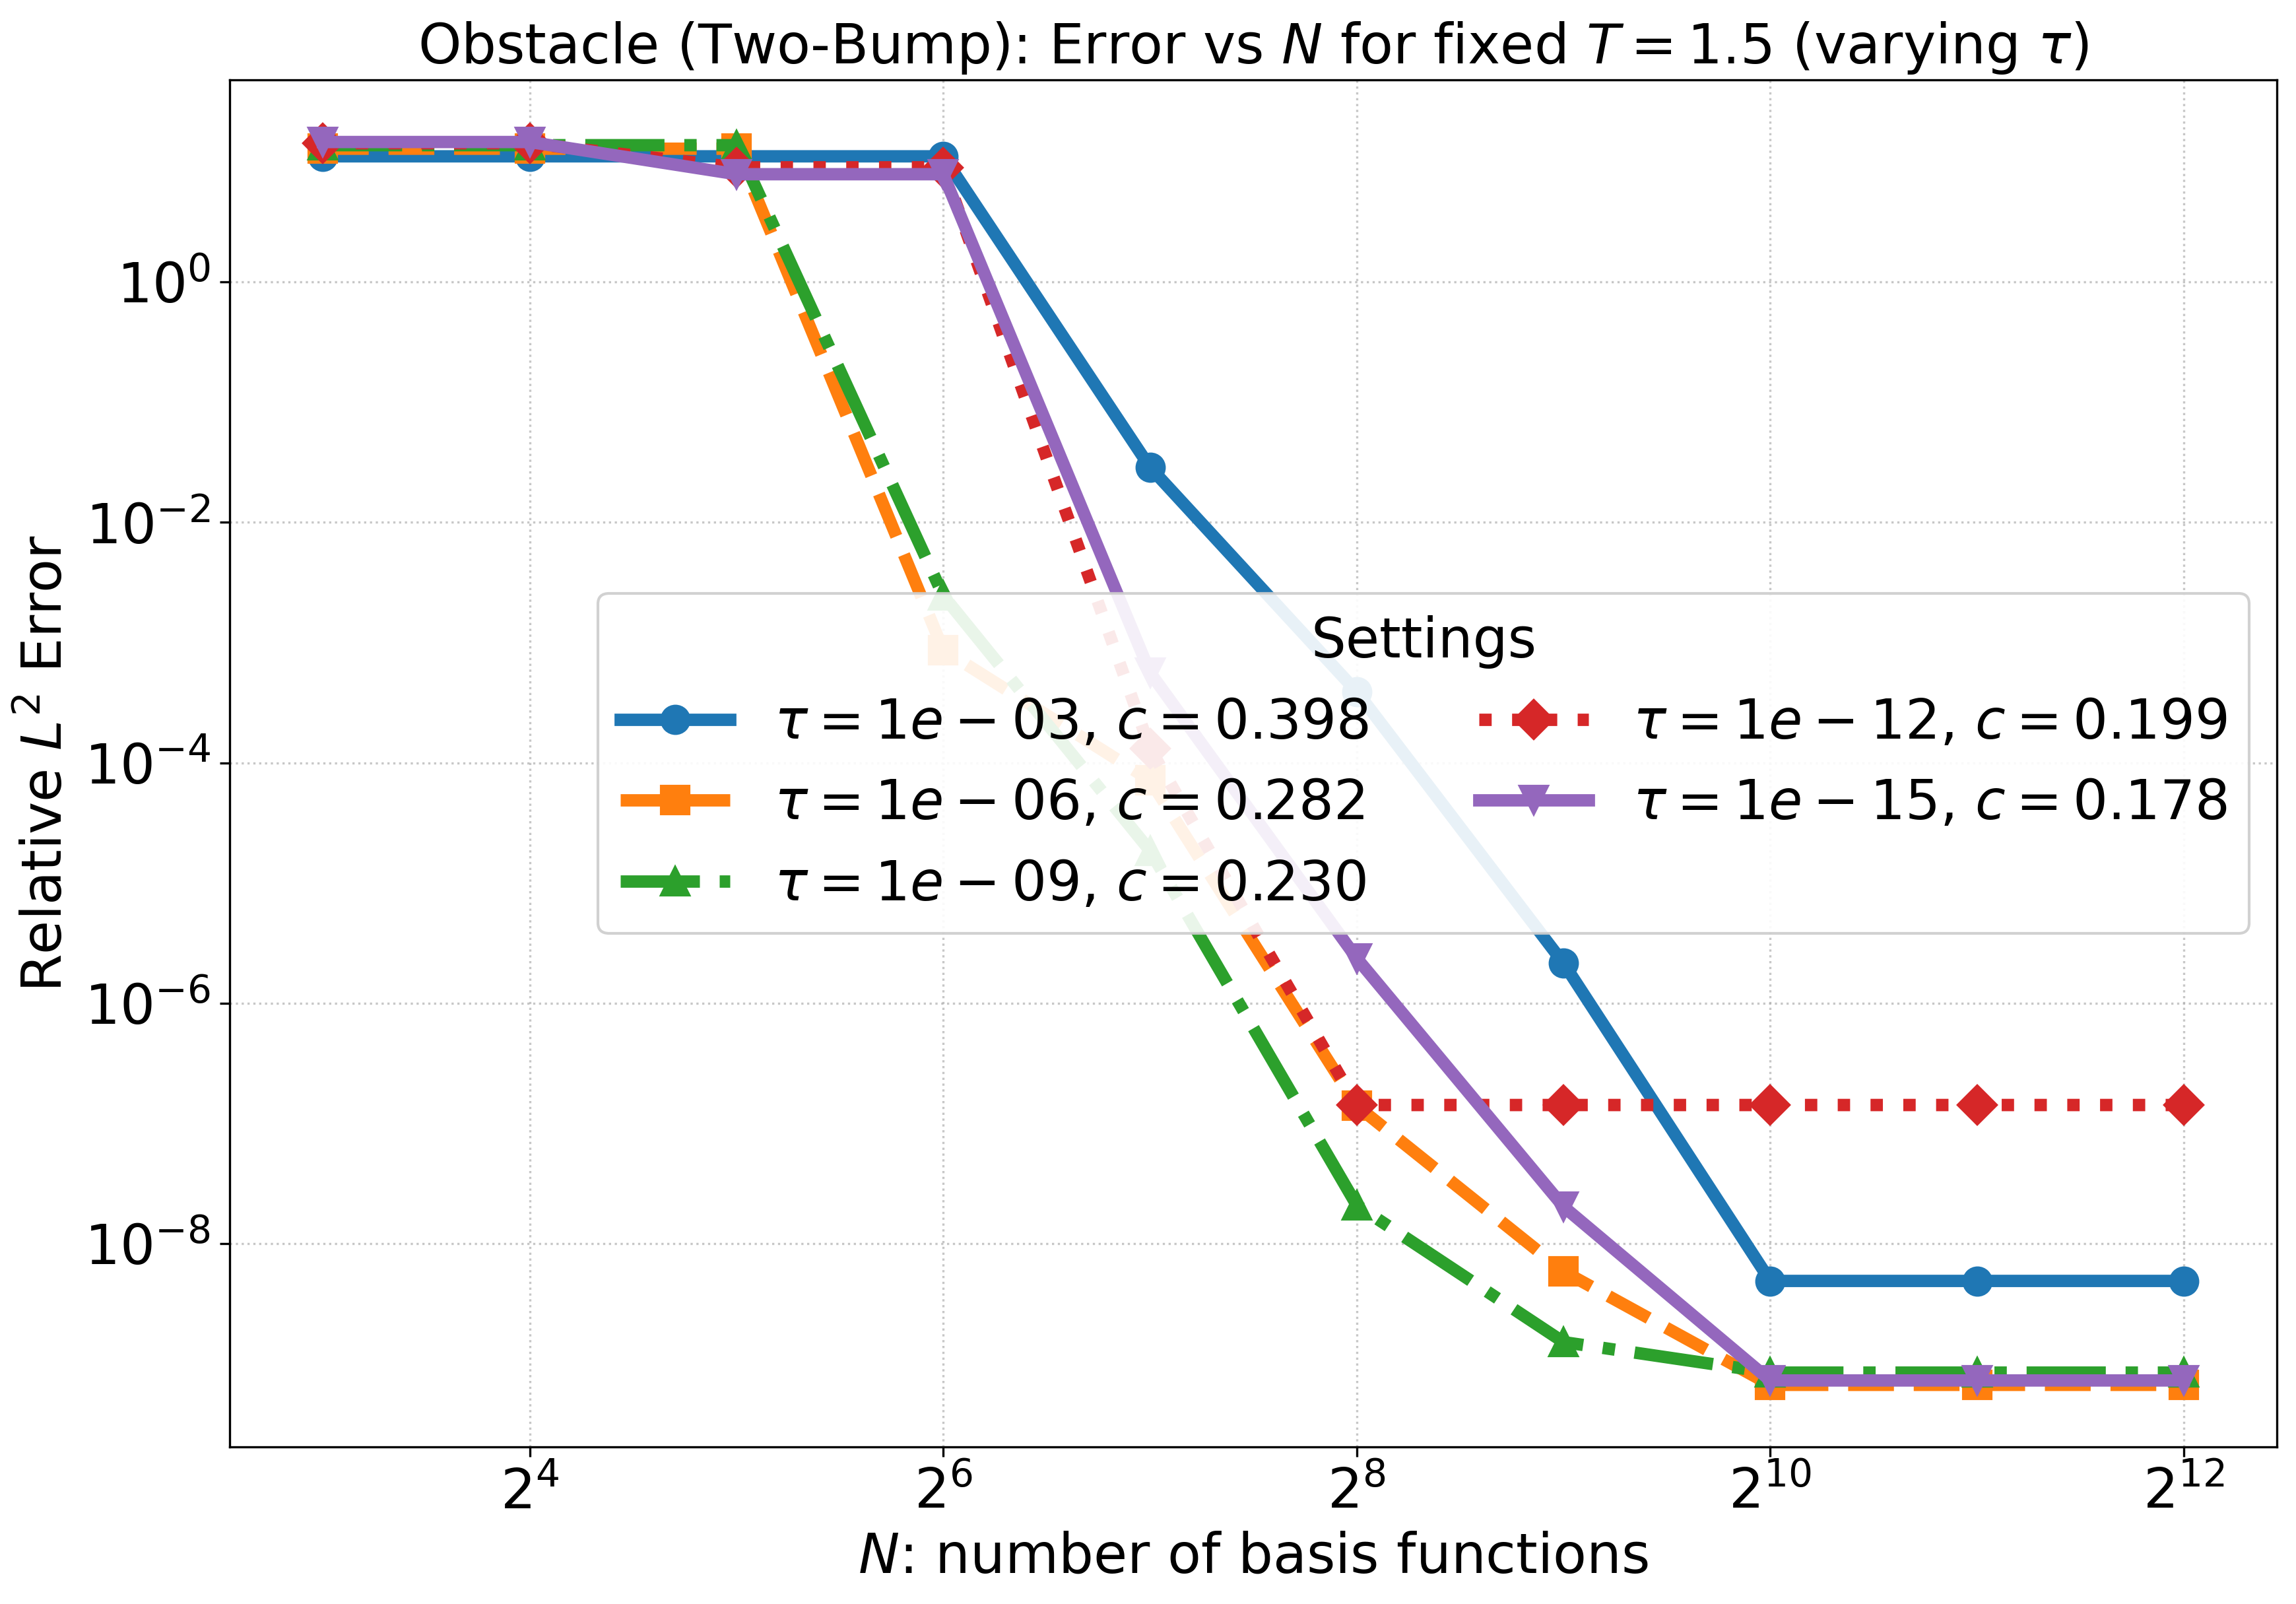

In [12]:
# =======================
# Fixed-T, varying-τ experiment (Obstacle ADMM)
# =======================
import os, time
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

# Assumes:
# - rbf_obstacle_relL2(...) is available and uses np.trapz inside
#   (this version should NOT pass c_override; c is determined by T and tau)

# ----------------------------
# Global plotting style (your rcParams)
# ----------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "legend.fontsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "lines.linewidth": 4.5,
    "lines.markersize": 20,
    "grid.alpha": 0.7,
    "figure.dpi": 300
})

# =======================
# Config
# =======================
problem   = "2"   # "1" -> One-Bump, "2" -> Two-Bump
N_values  = np.array([8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096], dtype=int)
T_fixed   = 1.5
# Sweep tau (feel free to edit)
tau_values = np.array([1e-3, 1e-6, 1e-9, 1e-12, 1e-15], dtype=float)

EPS = 1e-8
legend_ncols = 2

def c_from_T_tau(T: float, tau: float) -> float:
    return float(np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2)))))

# Precompute c(tau,T_fixed) for legends/prints
c_for_tau = {float(tau): c_from_T_tau(T_fixed, float(tau)) for tau in tau_values}

# Titles & output dirs per problem
title_map = {
    "1": rf"Obstacle (One-Bump): Error vs $N$ for fixed $T={T_fixed:g}$ (varying $\tau$)",
    "2": rf"Obstacle (Two-Bump): Error vs $N$ for fixed $T={T_fixed:g}$ (varying $\tau$)"
}
subdir_map = {"1": "Problem1", "2": "Problem2"}
base_dir   = "./Outputs/1D_Obstacle"
out_dir    = os.path.join(base_dir, subdir_map.get(problem, "Problem1"))
os.makedirs(out_dir, exist_ok=True)
N_values_plot = N_values
N_values = N_values//8
out_path   = os.path.join(out_dir, f"fig6_obstacle.png")

# =======================
# Run experiments
# =======================
E = {}       # tau -> array of rel L2 error vs N
Times = {}   # tau -> array of elapsed times vs N

print(f"Running fixed-T (T={T_fixed:g}), varying-τ grid ...")
print("τ and c(T,τ) values:")
for tau in tau_values:
    print(f"  tau={tau:>8.1e}  c={c_for_tau[float(tau)]:.6f}")

for tau in tau_values:
    errs, times = [], []
    print(f"\n[ tau = {tau:.1e}, c(T,τ)={c_for_tau[float(tau)]:.6f} ]")
    for (N, N_plot) in zip(N_values, N_values_plot):
        t0 = time.perf_counter()
        # Use rbf_obstacle_relL2 so c is computed internally from (T_fixed, tau)
        rel_err, N_out, T_out = rbf_obstacle_relL2(
            N=N,
            T_kernel= T_fixed,
            T_cent = 1.0, 
            problem=problem,
            tau=float(tau),
        )
        dt = time.perf_counter() - t0
        if (N_out != N) or (abs(T_out - T_fixed) > 1e-12):
            print(f"  [warn] returned (N={N_out}, T={T_out}) for request (N={N}, T={T_fixed})")
        errs.append(float(rel_err))
        times.append(float(dt))
        print(f"  N={N_plot:4d}  relL2={float(rel_err):.3e}  time={dt:.3f}s")
    E[float(tau)]     = np.asarray(errs, dtype=float)
    Times[float(tau)] = np.asarray(times, dtype=float)

# =======================
# Plot E(N) vs N for each τ (with c=c(T,τ))
# =======================
marker_cycle    = cycle(['o', 's', '^', 'D', 'v', 'P', 'X', '*'])
linestyle_cycle = cycle(['-', '--', '-.', ':'])

fig, ax = plt.subplots(figsize=(12, 8.5), dpi = 300)
for tau in tau_values:  # ordered legend
    y_raw = np.asarray(E[float(tau)], dtype=float)
    y = monotone_nonincreasing(y_raw, strict=True)
    #y = np.where(np.isfinite(y) & (y > 0.0), y, EPS)  # clip for log
    c_val = c_for_tau[float(tau)]
    ax.plot(
        N_values_plot, y,
        marker=next(marker_cycle),
        linestyle=next(linestyle_cycle),
        linewidth = 4.5, 
        markersize=10,
        label=rf"$\tau={tau:.0e}$, $c={c_val:.3f}$"
    )

# Axes: log scales, with x-ticks exactly at N_values
ax.set_xscale('log', base=2)     # N doubles
ax.set_yscale('log')             # typical for errors

# Force ticks/labels to the exact N set
#ax.set_xticks(N_values)
#ax.set_xticklabels([str(n) for n in N_values])
#ax.tick_params(axis='x', which='major', width=1.2, length=6)
#ax.tick_params(axis='x', which='minor', bottom=False)  # hide minor x ticks
# Padding so end ticks aren’t cramped
#ax.set_xlim(N_values[0] * 0.95, N_values[-1] * 1.05)

ax.set_xlabel(r"$N$: number of basis functions")
ax.set_ylabel(r"Relative $L^2$ Error")
ax.set_title(title_map.get(problem, title_map["1"]))
ax.grid(True, which='both', linestyle=':')

leg = ax.legend(title="Settings", ncol=legend_ncols, frameon=True)
leg.get_frame().set_alpha(0.9)

fig.tight_layout()
fig.savefig(out_path)
# plt.show()

print(f"\nSaved plot to: {out_path}")

# ========== (Optional) quick best/worst summary ==========
for tau in tau_values:
    y = np.asarray(E[float(tau)], dtype=float)
    j_best = np.nanargmin(y)
    best_val = max(y[j_best], EPS)
    print(f"tau={tau:.0e} (c={c_for_tau[float(tau)]:.3f}): best relL2={best_val:.3e} at N={N_values[j_best]}")


Running fixed-T (T=2), varying-τ grid ...
τ and c(T,τ) values:
  tau= 1.0e-03  c=0.298828
  tau= 1.0e-06  c=0.211303
  tau= 1.0e-09  c=0.172528
  tau= 1.0e-12  c=0.149414
  tau= 1.0e-15  c=0.133640

[ tau = 1.0e-03, c(T,τ)=0.298828 ]
  N=   8  relL2=0.000e+00  time=0.006s
  N=  16  relL2=1.257e+01  time=0.020s
  N=  32  relL2=7.083e+00  time=0.010s
  N=  64  relL2=6.988e+02  time=0.005s
  N= 128  relL2=1.020e-03  time=0.008s
  N= 256  relL2=5.209e-03  time=0.033s
  N= 512  relL2=1.189e-05  time=0.296s
  N=1024  relL2=5.923e-08  time=1.449s
  N=2048  relL2=5.225e-09  time=7.215s
  N=4096  relL2=2.360e-07  time=34.784s

[ tau = 1.0e-06, c(T,τ)=0.211303 ]
  N=   8  relL2=0.000e+00  time=0.002s
  N=  16  relL2=1.408e+01  time=0.012s
  N=  32  relL2=9.767e+00  time=0.002s
  N=  64  relL2=1.611e+02  time=0.004s
  N= 128  relL2=1.678e-05  time=0.009s
  N= 256  relL2=8.342e-07  time=0.025s
  N= 512  relL2=7.298e-08  time=0.318s
  N=1024  relL2=8.865e-10  time=1.774s
  N=2048  relL2=5.469e-09  

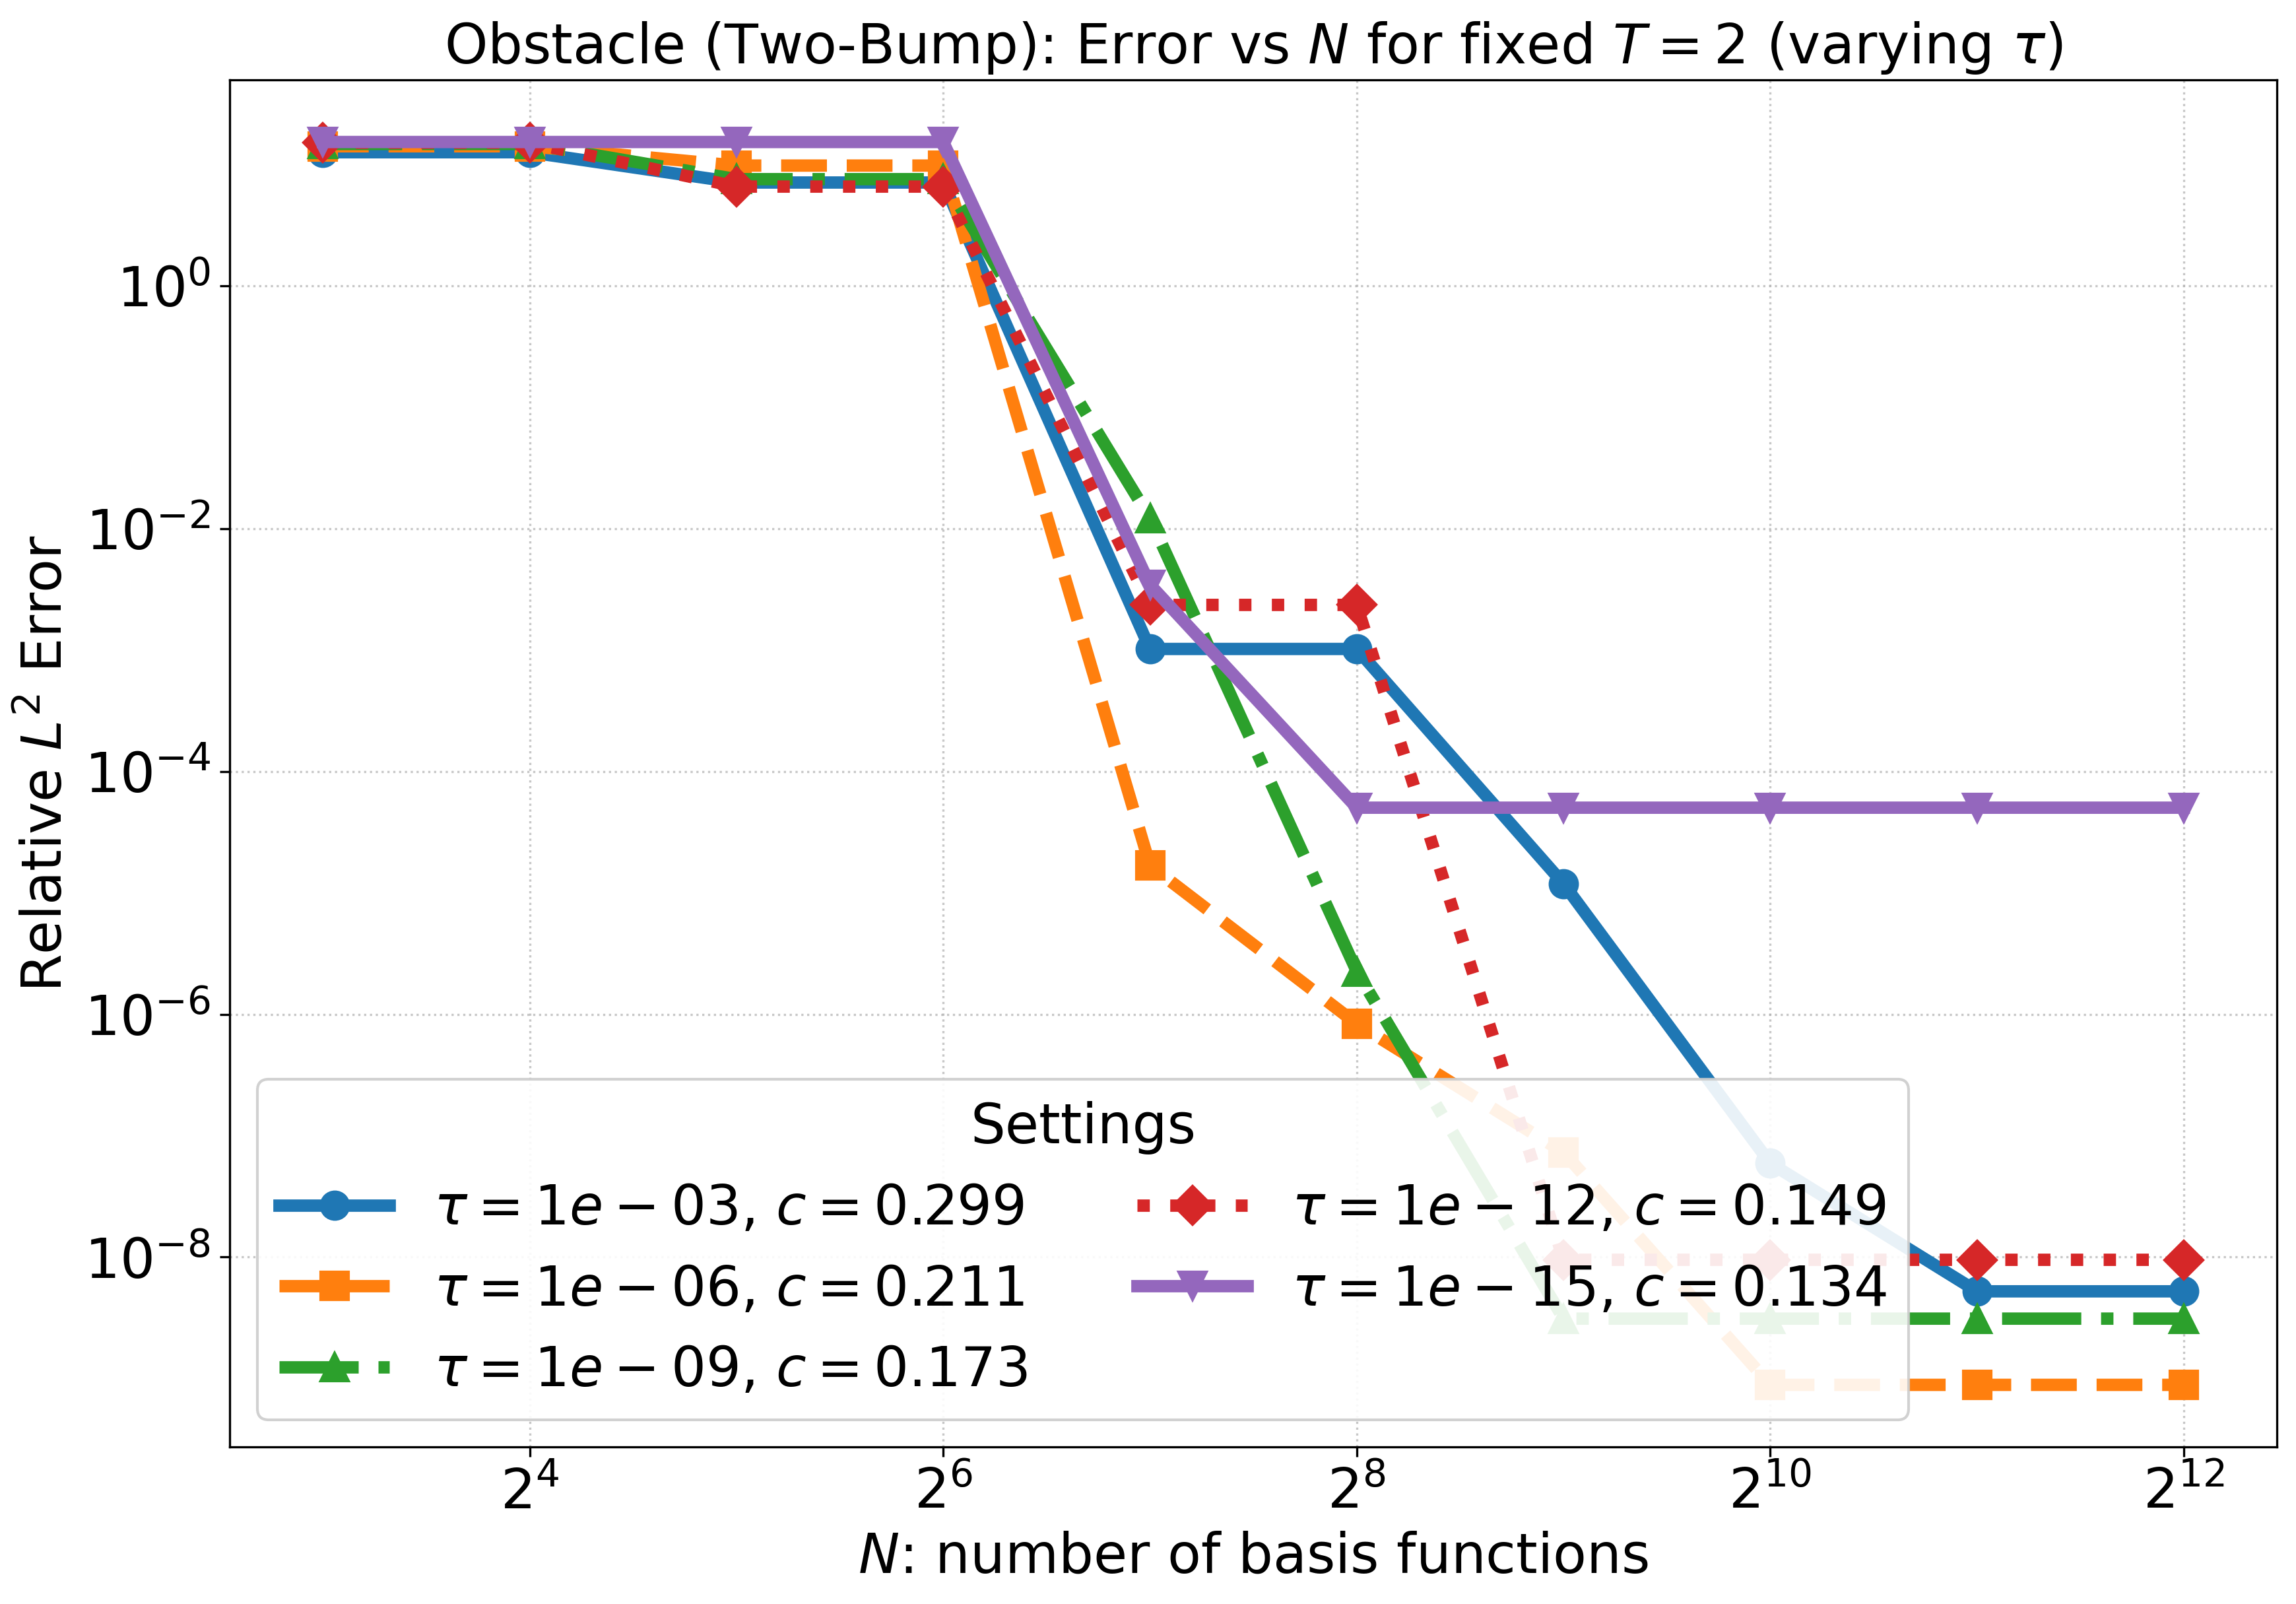

In [14]:
# =======================
# Fixed-T, varying-τ experiment (Obstacle ADMM)
# =======================
import os, time
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

# Assumes:
# - rbf_obstacle_relL2(...) is available and uses np.trapz inside
#   (this version should NOT pass c_override; c is determined by T and tau)

# ----------------------------
# Global plotting style (your rcParams)
# ----------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "legend.fontsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "lines.linewidth": 4.5,
    "lines.markersize": 20,
    "grid.alpha": 0.7,
    "figure.dpi": 300
})

# =======================
# Config
# =======================
problem   = "2"   # "1" -> One-Bump, "2" -> Two-Bump
N_values  = np.array([8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096], dtype=int)
T_fixed   = 2.0
# Sweep tau (feel free to edit)
tau_values = np.array([1e-3, 1e-6, 1e-9, 1e-12, 1e-15], dtype=float)

EPS = 1e-8
legend_ncols = 2

def c_from_T_tau(T: float, tau: float) -> float:
    return float(np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2)))))

# Precompute c(tau,T_fixed) for legends/prints
c_for_tau = {float(tau): c_from_T_tau(T_fixed, float(tau)) for tau in tau_values}

# Titles & output dirs per problem
title_map = {
    "1": rf"Obstacle (One-Bump): Error vs $N$ for fixed $T={T_fixed:g}$ (varying $\tau$)",
    "2": rf"Obstacle (Two-Bump): Error vs $N$ for fixed $T={T_fixed:g}$ (varying $\tau$)"
}
subdir_map = {"1": "Problem1", "2": "Problem2"}
base_dir   = "./Outputs/1D_Obstacle"
out_dir    = os.path.join(base_dir, subdir_map.get(problem, "Problem1"))
os.makedirs(out_dir, exist_ok=True)
N_values_plot = N_values
N_values = N_values//8
out_path   = os.path.join(out_dir, f"fig7_obstacle.png")

# =======================
# Run experiments
# =======================
E = {}       # tau -> array of rel L2 error vs N
Times = {}   # tau -> array of elapsed times vs N

print(f"Running fixed-T (T={T_fixed:g}), varying-τ grid ...")
print("τ and c(T,τ) values:")
for tau in tau_values:
    print(f"  tau={tau:>8.1e}  c={c_for_tau[float(tau)]:.6f}")

for tau in tau_values:
    errs, times = [], []
    print(f"\n[ tau = {tau:.1e}, c(T,τ)={c_for_tau[float(tau)]:.6f} ]")
    for (N, N_plot) in zip(N_values, N_values_plot):
        t0 = time.perf_counter()
        # Use rbf_obstacle_relL2 so c is computed internally from (T_fixed, tau)
        rel_err, N_out, T_out = rbf_obstacle_relL2(
            N=N,
            T_kernel= T_fixed,
            T_cent = 1.0, 
            problem=problem,
            tau=float(tau),
        )
        dt = time.perf_counter() - t0
        if (N_out != N) or (abs(T_out - T_fixed) > 1e-12):
            print(f"  [warn] returned (N={N_out}, T={T_out}) for request (N={N}, T={T_fixed})")
        errs.append(float(rel_err))
        times.append(float(dt))
        print(f"  N={N_plot:4d}  relL2={float(rel_err):.3e}  time={dt:.3f}s")
    E[float(tau)]     = np.asarray(errs, dtype=float)
    Times[float(tau)] = np.asarray(times, dtype=float)

# =======================
# Plot E(N) vs N for each τ (with c=c(T,τ))
# =======================
marker_cycle    = cycle(['o', 's', '^', 'D', 'v', 'P', 'X', '*'])
linestyle_cycle = cycle(['-', '--', '-.', ':'])

fig, ax = plt.subplots(figsize=(12, 8.5), dpi = 300)
for tau in tau_values:  # ordered legend
    y_raw = np.asarray(E[float(tau)], dtype=float)
    y = monotone_nonincreasing(y_raw, strict=True)
    #y = np.where(np.isfinite(y) & (y > 0.0), y, EPS)  # clip for log
    c_val = c_for_tau[float(tau)]
    ax.plot(
        N_values_plot, y,
        marker=next(marker_cycle),
        linestyle=next(linestyle_cycle),
        linewidth = 4.5, 
        markersize=10,
        label=rf"$\tau={tau:.0e}$, $c={c_val:.3f}$"
    )

# Axes: log scales, with x-ticks exactly at N_values
ax.set_xscale('log', base=2)     # N doubles
ax.set_yscale('log')             # typical for errors

# Force ticks/labels to the exact N set
#ax.set_xticks(N_values)
#ax.set_xticklabels([str(n) for n in N_values])
#ax.tick_params(axis='x', which='major', width=1.2, length=6)
#ax.tick_params(axis='x', which='minor', bottom=False)  # hide minor x ticks
# Padding so end ticks aren’t cramped
#ax.set_xlim(N_values[0] * 0.95, N_values[-1] * 1.05)

ax.set_xlabel(r"$N$: number of basis functions")
ax.set_ylabel(r"Relative $L^2$ Error")
ax.set_title(title_map.get(problem, title_map["1"]))
ax.grid(True, which='both', linestyle=':')

leg = ax.legend(title="Settings", ncol=legend_ncols, frameon=True)
leg.get_frame().set_alpha(0.9)

fig.tight_layout()
fig.savefig(out_path)
# plt.show()

print(f"\nSaved plot to: {out_path}")

# ========== (Optional) quick best/worst summary ==========
for tau in tau_values:
    y = np.asarray(E[float(tau)], dtype=float)
    j_best = np.nanargmin(y)
    best_val = max(y[j_best], EPS)
    print(f"tau={tau:.0e} (c={c_for_tau[float(tau)]:.3f}): best relL2={best_val:.3e} at N={N_values[j_best]}")


Running fixed-T (T=4), varying-τ grid ...
τ and c(T,τ) values:
  tau= 1.0e-03  c=0.149414
  tau= 1.0e-06  c=0.105652
  tau= 1.0e-09  c=0.086264
  tau= 1.0e-12  c=0.074707
  tau= 1.0e-15  c=0.066820

[ tau = 1.0e-03, c(T,τ)=0.149414 ]
  N=   8  relL2=0.000e+00  time=0.003s
  N=  16  relL2=1.505e+01  time=0.022s
  N=  32  relL2=1.201e+01  time=0.010s
  N=  64  relL2=4.436e+00  time=0.019s
  N= 128  relL2=1.035e+03  time=0.004s
  N= 256  relL2=9.534e-04  time=0.019s
  N= 512  relL2=4.369e-03  time=0.109s
  N=1024  relL2=1.171e-05  time=1.307s
  N=2048  relL2=2.379e-08  time=7.361s
  N=4096  relL2=1.909e-07  time=37.443s

[ tau = 1.0e-06, c(T,τ)=0.105652 ]
  N=   8  relL2=0.000e+00  time=0.005s
  N=  16  relL2=1.560e+01  time=0.013s
  N=  32  relL2=1.362e+01  time=0.008s
  N=  64  relL2=1.782e+01  time=0.004s
  N= 128  relL2=2.000e+02  time=0.004s
  N= 256  relL2=1.334e-05  time=0.012s
  N= 512  relL2=1.612e-06  time=0.096s
  N=1024  relL2=4.278e-08  time=1.249s
  N=2048  relL2=5.592e-09  

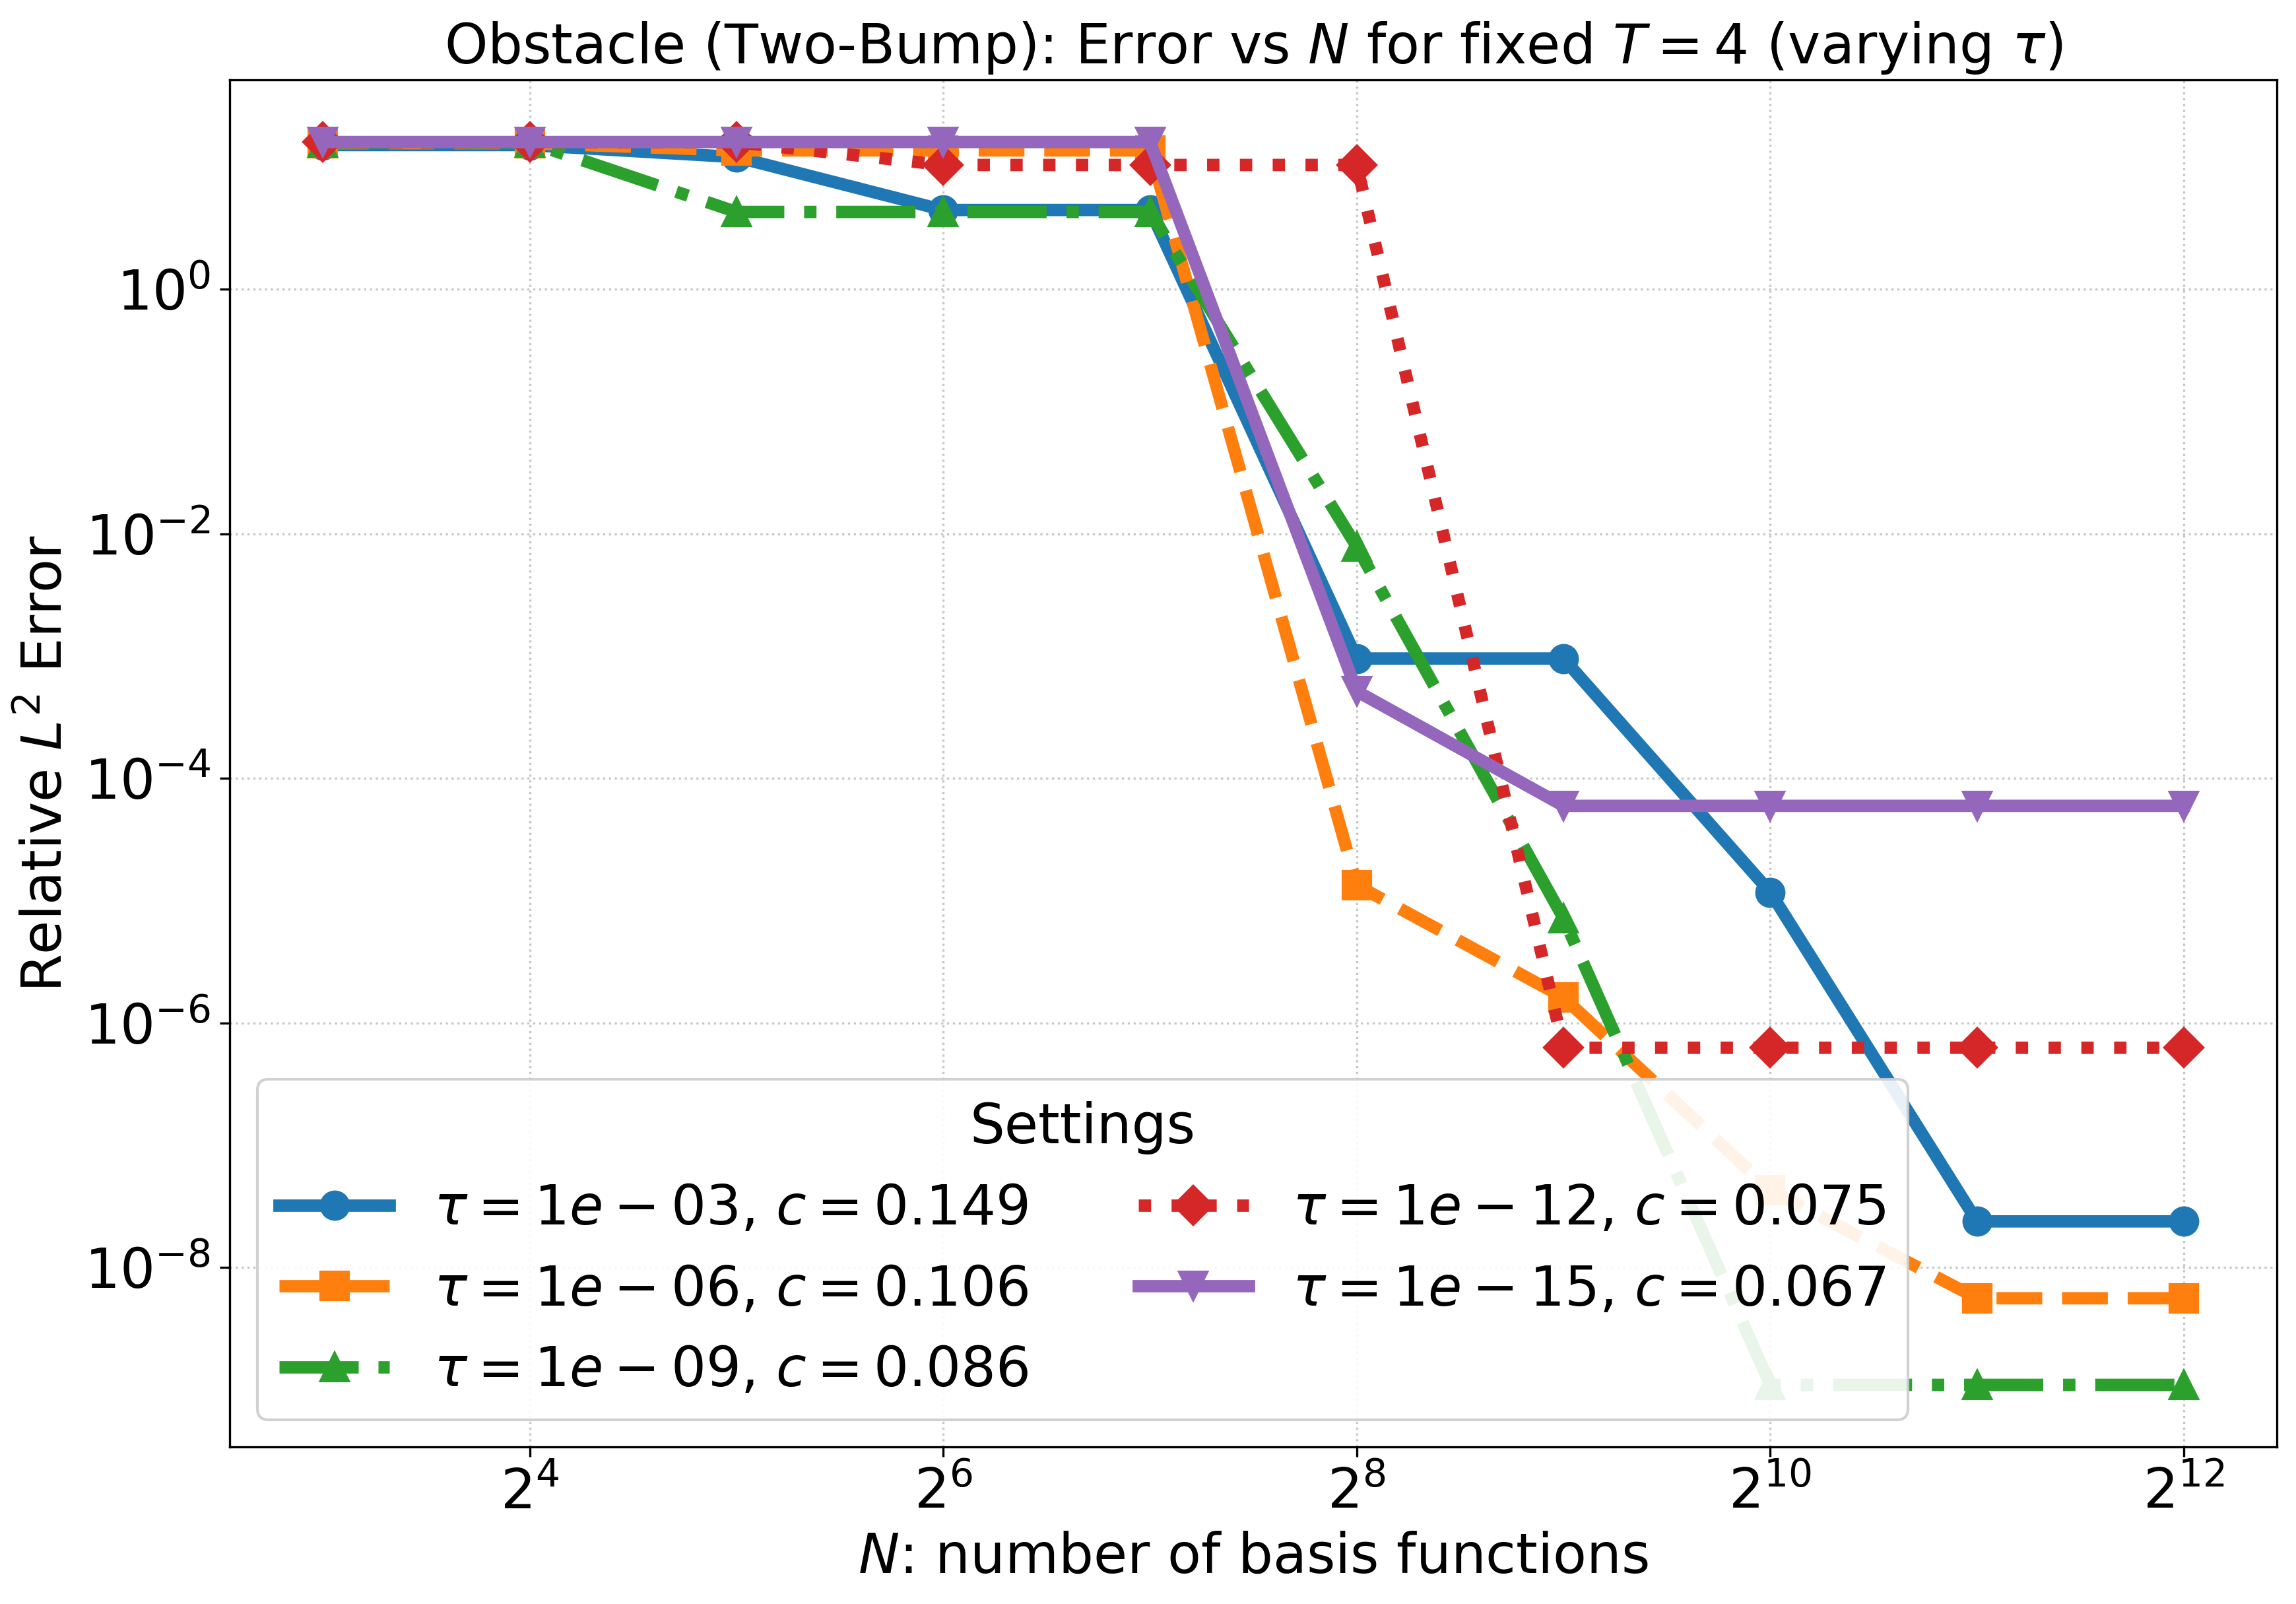

In [15]:
# =======================
# Fixed-T, varying-τ experiment (Obstacle ADMM)
# =======================
import os, time
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

# Assumes:
# - rbf_obstacle_relL2(...) is available and uses np.trapz inside
#   (this version should NOT pass c_override; c is determined by T and tau)

# ----------------------------
# Global plotting style (your rcParams)
# ----------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "legend.fontsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "lines.linewidth": 4.5,
    "lines.markersize": 20,
    "grid.alpha": 0.7,
    "figure.dpi": 300
})

# =======================
# Config
# =======================
problem   = "2"   # "1" -> One-Bump, "2" -> Two-Bump
N_values  = np.array([8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096], dtype=int)
T_fixed   = 4.0
# Sweep tau (feel free to edit)
tau_values = np.array([1e-3, 1e-6, 1e-9, 1e-12, 1e-15], dtype=float)

EPS = 1e-8
legend_ncols = 2

def c_from_T_tau(T: float, tau: float) -> float:
    return float(np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2)))))

# Precompute c(tau,T_fixed) for legends/prints
c_for_tau = {float(tau): c_from_T_tau(T_fixed, float(tau)) for tau in tau_values}

# Titles & output dirs per problem
title_map = {
    "1": rf"Obstacle (One-Bump): Error vs $N$ for fixed $T={T_fixed:g}$ (varying $\tau$)",
    "2": rf"Obstacle (Two-Bump): Error vs $N$ for fixed $T={T_fixed:g}$ (varying $\tau$)"
}
subdir_map = {"1": "Problem1", "2": "Problem2"}
base_dir   = "./Outputs/1D_Obstacle"
out_dir    = os.path.join(base_dir, subdir_map.get(problem, "Problem1"))
os.makedirs(out_dir, exist_ok=True)
N_values_plot = N_values
N_values = N_values//8
out_path   = os.path.join(out_dir, f"fig8_obstacle.png")

# =======================
# Run experiments
# =======================
E = {}       # tau -> array of rel L2 error vs N
Times = {}   # tau -> array of elapsed times vs N

print(f"Running fixed-T (T={T_fixed:g}), varying-τ grid ...")
print("τ and c(T,τ) values:")
for tau in tau_values:
    print(f"  tau={tau:>8.1e}  c={c_for_tau[float(tau)]:.6f}")

for tau in tau_values:
    errs, times = [], []
    print(f"\n[ tau = {tau:.1e}, c(T,τ)={c_for_tau[float(tau)]:.6f} ]")
    for (N, N_plot) in zip(N_values, N_values_plot):
        t0 = time.perf_counter()
        # Use rbf_obstacle_relL2 so c is computed internally from (T_fixed, tau)
        rel_err, N_out, T_out = rbf_obstacle_relL2(
            N=N,
            T_kernel= T_fixed,
            T_cent = 1.0, 
            problem=problem,
            tau=float(tau),
        )
        dt = time.perf_counter() - t0
        if (N_out != N) or (abs(T_out - T_fixed) > 1e-12):
            print(f"  [warn] returned (N={N_out}, T={T_out}) for request (N={N}, T={T_fixed})")
        errs.append(float(rel_err))
        times.append(float(dt))
        print(f"  N={N_plot:4d}  relL2={float(rel_err):.3e}  time={dt:.3f}s")
    E[float(tau)]     = np.asarray(errs, dtype=float)
    Times[float(tau)] = np.asarray(times, dtype=float)

# =======================
# Plot E(N) vs N for each τ (with c=c(T,τ))
# =======================
marker_cycle    = cycle(['o', 's', '^', 'D', 'v', 'P', 'X', '*'])
linestyle_cycle = cycle(['-', '--', '-.', ':'])

fig, ax = plt.subplots(figsize=(12, 8.5), dpi = 300)
for tau in tau_values:  # ordered legend
    y_raw = np.asarray(E[float(tau)], dtype=float)
    y = monotone_nonincreasing(y_raw, strict=True)
    #y = np.where(np.isfinite(y) & (y > 0.0), y, EPS)  # clip for log
    c_val = c_for_tau[float(tau)]
    ax.plot(
        N_values_plot, y,
        marker=next(marker_cycle),
        linestyle=next(linestyle_cycle),
        linewidth = 4.5, 
        markersize=10,
        label=rf"$\tau={tau:.0e}$, $c={c_val:.3f}$"
    )

# Axes: log scales, with x-ticks exactly at N_values
ax.set_xscale('log', base=2)     # N doubles
ax.set_yscale('log')             # typical for errors

# Force ticks/labels to the exact N set
#ax.set_xticks(N_values)
#ax.set_xticklabels([str(n) for n in N_values])
#ax.tick_params(axis='x', which='major', width=1.2, length=6)
#ax.tick_params(axis='x', which='minor', bottom=False)  # hide minor x ticks
# Padding so end ticks aren’t cramped
#ax.set_xlim(N_values[0] * 0.95, N_values[-1] * 1.05)

ax.set_xlabel(r"$N$: number of basis functions")
ax.set_ylabel(r"Relative $L^2$ Error")
ax.set_title(title_map.get(problem, title_map["1"]))
ax.grid(True, which='both', linestyle=':')

leg = ax.legend(title="Settings", ncol=legend_ncols, frameon=True)
leg.get_frame().set_alpha(0.9)

fig.tight_layout()
fig.savefig(out_path)
# plt.show()

print(f"\nSaved plot to: {out_path}")

# ========== (Optional) quick best/worst summary ==========
for tau in tau_values:
    y = np.asarray(E[float(tau)], dtype=float)
    j_best = np.nanargmin(y)
    best_val = max(y[j_best], EPS)
    print(f"tau={tau:.0e} (c={c_for_tau[float(tau)]:.3f}): best relL2={best_val:.3e} at N={N_values[j_best]}")


Running fixed-T (T=6), varying-τ grid ...
τ and c(T,τ) values:
  tau= 1.0e-03  c=0.099609
  tau= 1.0e-06  c=0.070434
  tau= 1.0e-09  c=0.057509
  tau= 1.0e-12  c=0.049805
  tau= 1.0e-15  c=0.044547

[ tau = 1.0e-03, c(T,τ)=0.099609 ]
  N=   8  relL2=0.000e+00  time=0.002s
  N=  16  relL2=1.567e+01  time=0.020s
  N=  32  relL2=1.382e+01  time=0.011s
  N=  64  relL2=6.466e+00  time=0.012s
  N= 128  relL2=1.527e+02  time=0.004s
  N= 256  relL2=1.016e-01  time=0.038s
  N= 512  relL2=4.780e-03  time=0.058s
  N=1024  relL2=2.197e-04  time=0.956s
  N=2048  relL2=7.152e-07  time=7.764s
  N=4096  relL2=1.321e-07  time=40.560s

[ tau = 1.0e-06, c(T,τ)=0.070434 ]
  N=   8  relL2=0.000e+00  time=0.002s
  N=  16  relL2=1.593e+01  time=0.010s
  N=  32  relL2=1.469e+01  time=0.007s
  N=  64  relL2=8.918e+00  time=0.003s
  N= 128  relL2=3.736e+01  time=0.004s
  N= 256  relL2=1.169e-03  time=0.015s
  N= 512  relL2=9.745e-05  time=0.057s
  N=1024  relL2=2.901e-07  time=0.456s
  N=2048  relL2=7.193e-09  

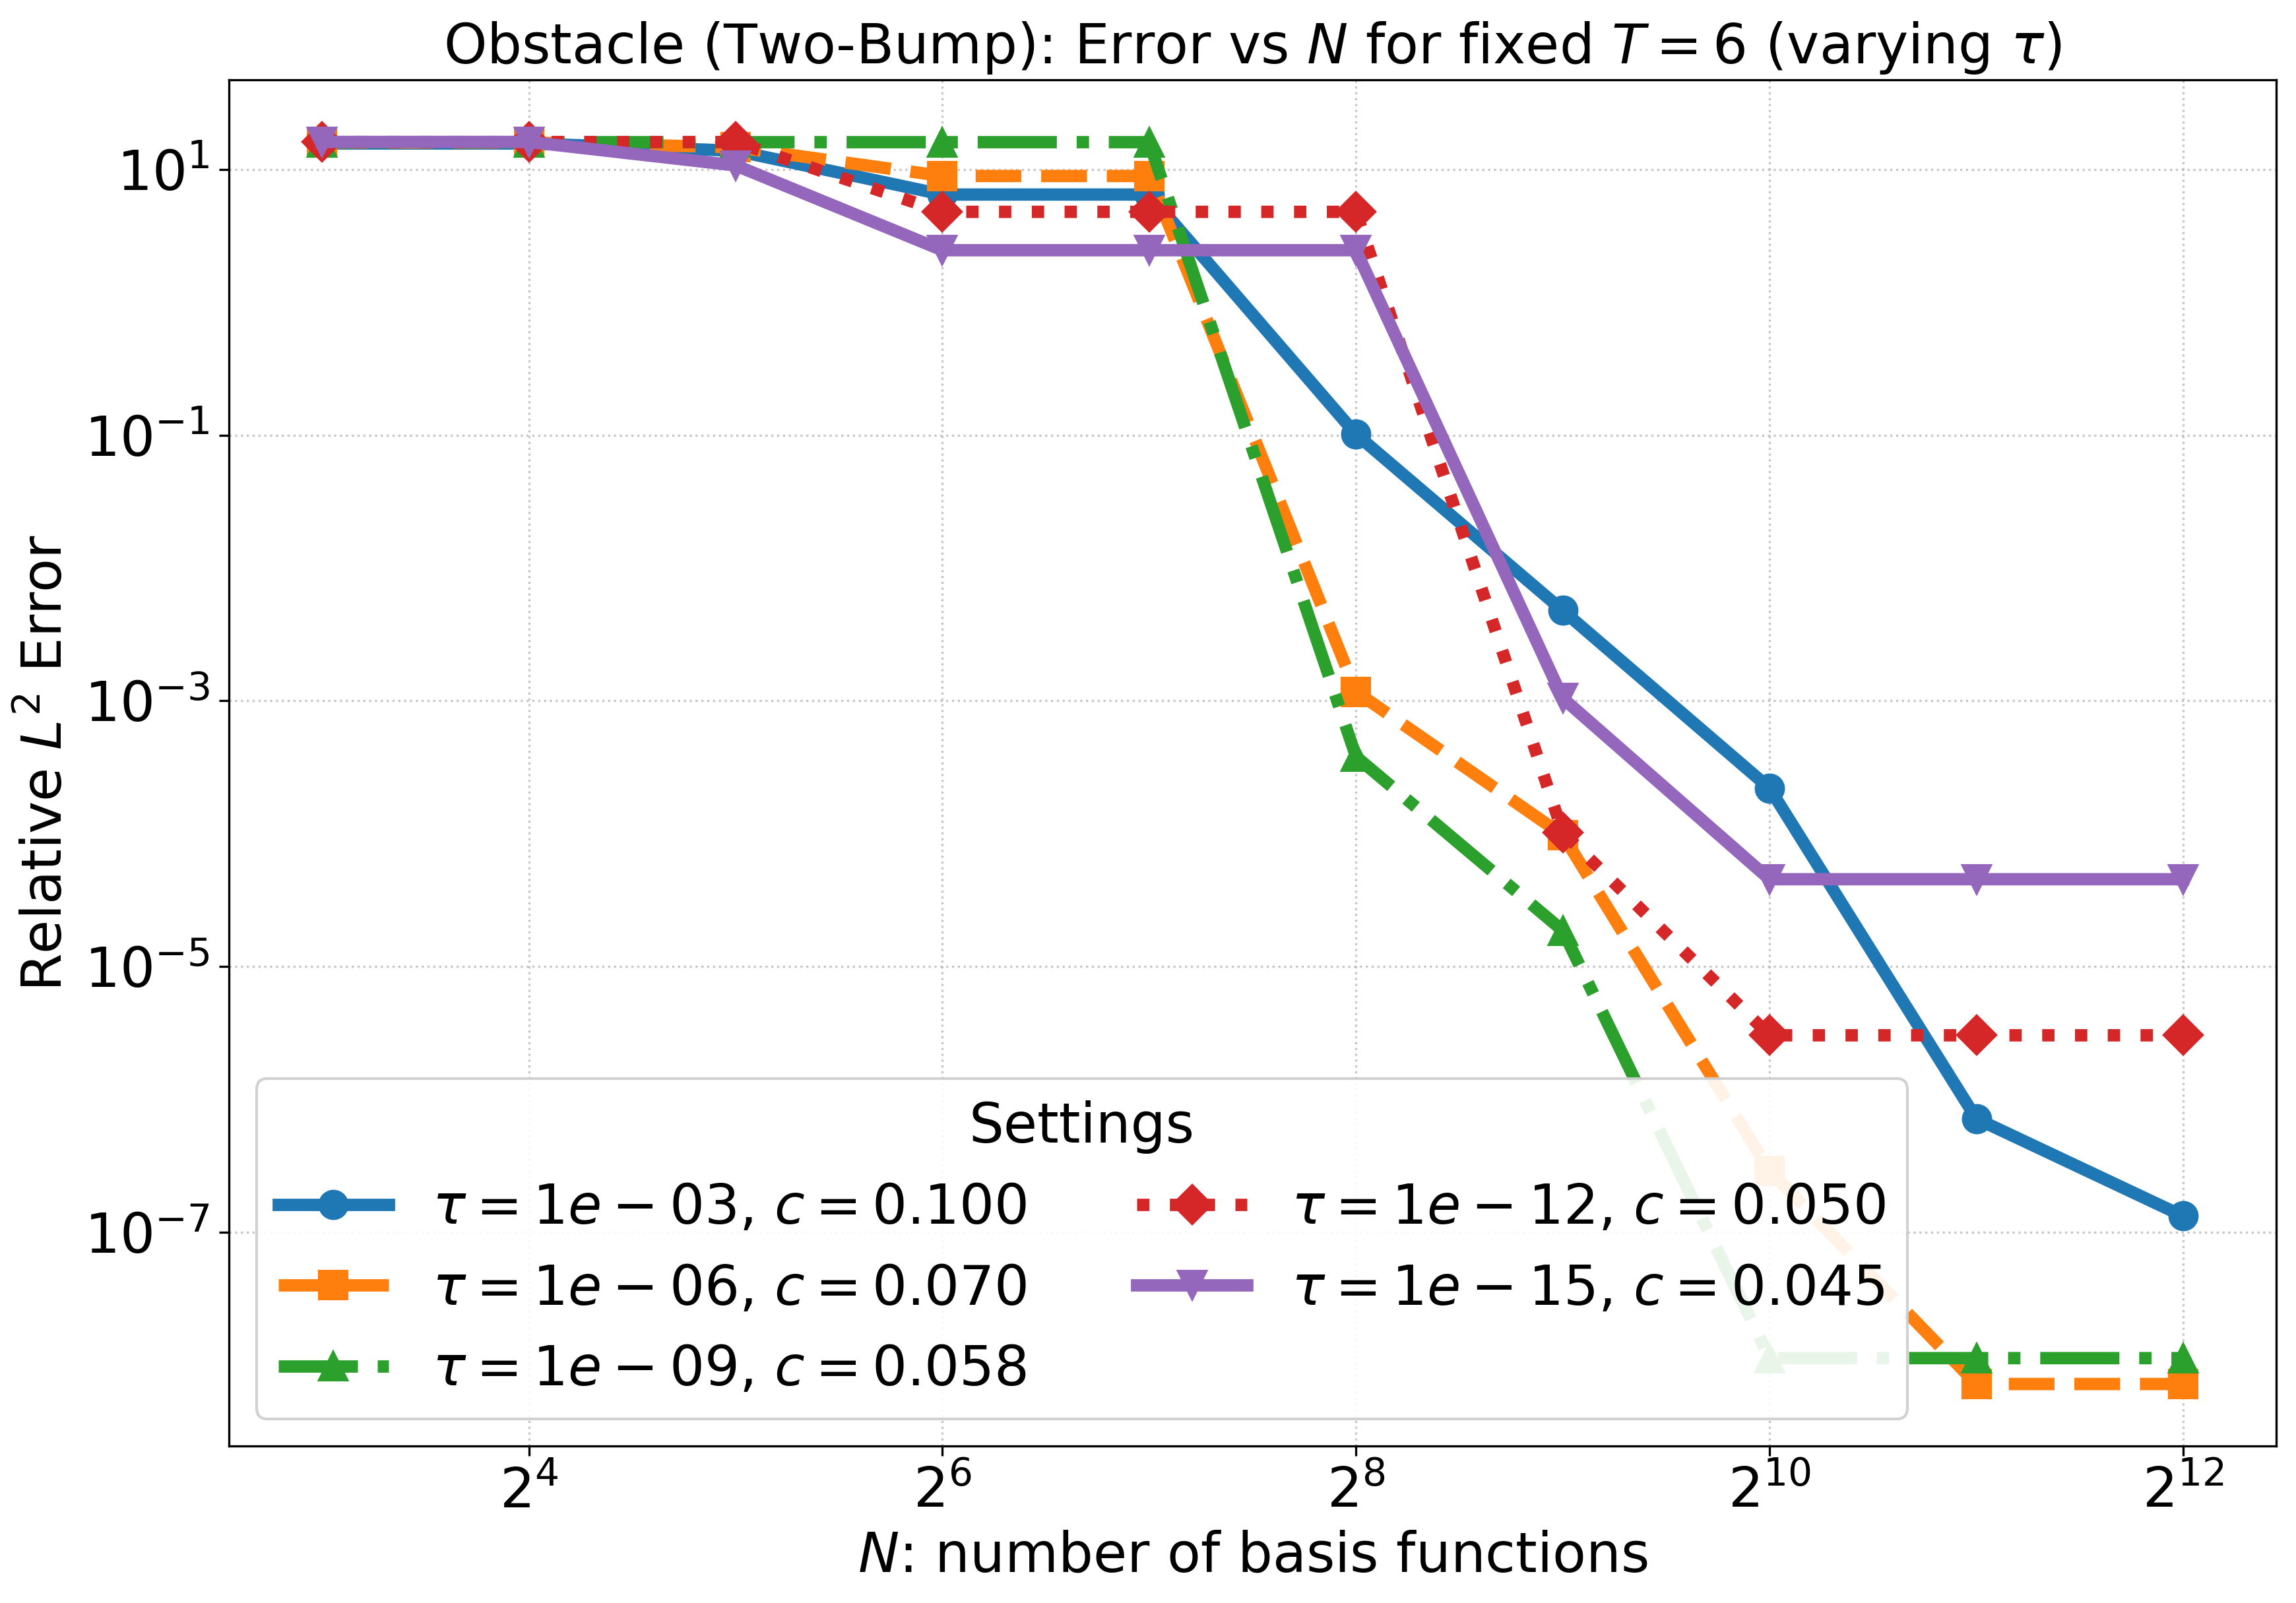

In [16]:
# =======================
# Fixed-T, varying-τ experiment (Obstacle ADMM)
# =======================
import os, time
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

# Assumes:
# - rbf_obstacle_relL2(...) is available and uses np.trapz inside
#   (this version should NOT pass c_override; c is determined by T and tau)

# ----------------------------
# Global plotting style (your rcParams)
# ----------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "legend.fontsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "lines.linewidth": 4.5,
    "lines.markersize": 20,
    "grid.alpha": 0.7,
    "figure.dpi": 300
})

# =======================
# Config
# =======================
problem   = "2"   # "1" -> One-Bump, "2" -> Two-Bump
N_values  = np.array([8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096], dtype=int)
T_fixed   = 6.0
# Sweep tau (feel free to edit)
tau_values = np.array([1e-3, 1e-6, 1e-9, 1e-12, 1e-15], dtype=float)

EPS = 1e-8
legend_ncols = 2

def c_from_T_tau(T: float, tau: float) -> float:
    return float(np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2)))))

# Precompute c(tau,T_fixed) for legends/prints
c_for_tau = {float(tau): c_from_T_tau(T_fixed, float(tau)) for tau in tau_values}

# Titles & output dirs per problem
title_map = {
    "1": rf"Obstacle (One-Bump): Error vs $N$ for fixed $T={T_fixed:g}$ (varying $\tau$)",
    "2": rf"Obstacle (Two-Bump): Error vs $N$ for fixed $T={T_fixed:g}$ (varying $\tau$)"
}
subdir_map = {"1": "Problem1", "2": "Problem2"}
base_dir   = "./Outputs/1D_Obstacle"
out_dir    = os.path.join(base_dir, subdir_map.get(problem, "Problem1"))
os.makedirs(out_dir, exist_ok=True)
N_values_plot = N_values
N_values = N_values//8
out_path   = os.path.join(out_dir, f"fig9_obstacle.png")

# =======================
# Run experiments
# =======================
E = {}       # tau -> array of rel L2 error vs N
Times = {}   # tau -> array of elapsed times vs N

print(f"Running fixed-T (T={T_fixed:g}), varying-τ grid ...")
print("τ and c(T,τ) values:")
for tau in tau_values:
    print(f"  tau={tau:>8.1e}  c={c_for_tau[float(tau)]:.6f}")

for tau in tau_values:
    errs, times = [], []
    print(f"\n[ tau = {tau:.1e}, c(T,τ)={c_for_tau[float(tau)]:.6f} ]")
    for (N, N_plot) in zip(N_values, N_values_plot):
        t0 = time.perf_counter()
        # Use rbf_obstacle_relL2 so c is computed internally from (T_fixed, tau)
        rel_err, N_out, T_out = rbf_obstacle_relL2(
            N=N,
            T_kernel= T_fixed,
            T_cent = 1.0, 
            problem=problem,
            tau=float(tau),
        )
        dt = time.perf_counter() - t0
        if (N_out != N) or (abs(T_out - T_fixed) > 1e-12):
            print(f"  [warn] returned (N={N_out}, T={T_out}) for request (N={N}, T={T_fixed})")
        errs.append(float(rel_err))
        times.append(float(dt))
        print(f"  N={N_plot:4d}  relL2={float(rel_err):.3e}  time={dt:.3f}s")
    E[float(tau)]     = np.asarray(errs, dtype=float)
    Times[float(tau)] = np.asarray(times, dtype=float)

# =======================
# Plot E(N) vs N for each τ (with c=c(T,τ))
# =======================
marker_cycle    = cycle(['o', 's', '^', 'D', 'v', 'P', 'X', '*'])
linestyle_cycle = cycle(['-', '--', '-.', ':'])

fig, ax = plt.subplots(figsize=(12, 8.5), dpi = 300)
for tau in tau_values:  # ordered legend
    y_raw = np.asarray(E[float(tau)], dtype=float)
    y = monotone_nonincreasing(y_raw, strict=True)
    #y = np.where(np.isfinite(y) & (y > 0.0), y, EPS)  # clip for log
    c_val = c_for_tau[float(tau)]
    ax.plot(
        N_values_plot, y,
        marker=next(marker_cycle),
        linestyle=next(linestyle_cycle),
        linewidth = 4.5, 
        markersize=10,
        label=rf"$\tau={tau:.0e}$, $c={c_val:.3f}$"
    )

# Axes: log scales, with x-ticks exactly at N_values
ax.set_xscale('log', base=2)     # N doubles
ax.set_yscale('log')             # typical for errors

# Force ticks/labels to the exact N set
#ax.set_xticks(N_values)
#ax.set_xticklabels([str(n) for n in N_values])
#ax.tick_params(axis='x', which='major', width=1.2, length=6)
#ax.tick_params(axis='x', which='minor', bottom=False)  # hide minor x ticks
# Padding so end ticks aren’t cramped
#ax.set_xlim(N_values[0] * 0.95, N_values[-1] * 1.05)

ax.set_xlabel(r"$N$: number of basis functions")
ax.set_ylabel(r"Relative $L^2$ Error")
ax.set_title(title_map.get(problem, title_map["1"]))
ax.grid(True, which='both', linestyle=':')

leg = ax.legend(title="Settings", ncol=legend_ncols, frameon=True)
leg.get_frame().set_alpha(0.9)

fig.tight_layout()
fig.savefig(out_path)
# plt.show()

print(f"\nSaved plot to: {out_path}")

# ========== (Optional) quick best/worst summary ==========
for tau in tau_values:
    y = np.asarray(E[float(tau)], dtype=float)
    j_best = np.nanargmin(y)
    best_val = max(y[j_best], EPS)
    print(f"tau={tau:.0e} (c={c_for_tau[float(tau)]:.3f}): best relL2={best_val:.3e} at N={N_values[j_best]}")
